# 02 - Modelamiento de asociaciones y predictivo.

En este notebook se ajusta el modelo multivariable de asociaciones (OE1) y se desarrollan, evalúan y
comparan los modelos predictivos preoperatorio y perioperatorio (OE2-OE4), sobre la cohorte construida
en `01_cohorte.ipynb`.

**Entrada:**
1. Catálogo metadatos
2. Parquet de la cohorte analítica y de la subcohorte espinal

**Salida:**
1. Tablas del manuscrito de ambos arcos
2. Predicciones fuera de pliegue por algoritmo y especificación
3. Figuras de desempeño, comparación e interpretabilidad

Las estimaciones del arco de asociaciones se interpretan como asociaciones multivariables ajustadas.
El conjunto de covariables no se construyó bajo un marco de inferencia causal, de modo que ningún
coeficiente ocupa una posición privilegiada respecto de los demás.

In [1]:
%load_ext autoreload
%autoreload 2

import sys, warnings
from pathlib import Path

import pandas as pd

sys.path.insert(0, str(Path.cwd()))
from utils import config, daten, statistik, vista, rendern, tabula, modell, evaluar

%matplotlib inline
from IPython.display import display

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 160)

# Las tablas del manuscrito se guardan completas en el cuaderno, que es el único
# registro publicado: por defecto pandas recorta a 10 filas todo lo que supere 60.
pd.set_option("display.max_rows", 250)

## 1. Insumos

Se cargan la cohorte analítica y el catálogo producidos por `01_cohorte.ipynb`. La subcohorte
espinal incorpora al cargarse la recodificación del manejo anestésico, que agrupa dosis y recuenta
agentes administrados de forma simultánea, según las reglas que documenta la tabla de
recodificaciones.

In [2]:
catalogo = daten.cargar_catalogo()
cohorte = pd.read_parquet(config.PROCESSED / "dataFONIS_prep.parquet")
espinal = daten.derivar_espinal(pd.read_parquet(config.PROCESSED / "dataFONIS_prep_espinal.parquet"))

print(f"cohorte analítica: {len(cohorte)} · eventos: {int(cohorte[config.OUTCOME].sum())}")
print(f"subcohorte espinal: {len(espinal)} · eventos: {int(espinal[config.OUTCOME].sum())}")

✔ contrato válido: 144 variables · 24 columnas blindadas
cohorte analítica: 714 · eventos: 423
subcohorte espinal: 690 · eventos: 411


## 2. Conjunto de covariables y diagnósticos

El conjunto de covariables del modelo de asociaciones se declara en el catálogo y no se selecciona
aquí. Reúne los factores de riesgo de dolor postcesárea reportados en la literatura y disponibles en
la cohorte, el centro como unidad de agrupamiento, el índice de masa corporal como ajustador y una
variable incorporada por su asociación bivariada y su estabilidad frente a la penalización.

Los eventos por parámetro y el diagnóstico de colinealidad se calculan como apoyo a esa decisión y no
como criterio de exclusión automático. El factor de inflación de la varianza se estima en su forma
generalizada, invariante al nivel de referencia de las categóricas de varios niveles.

In [3]:
asociativa = modell.configuracion_del_catalogo(catalogo, "Conjunto parsimonioso")

roles = catalogo.loc[catalogo["include_explicativo"].fillna(False),
                     ["var_rename", "label", "rol_explicativo"]]
print(asociativa)
roles.reset_index(drop=True)

Configuracion(Conjunto parsimonioso: 12 covariables)


,var_rename,label,rol_explicativo
0,hosp,Hospital,centro
1,edad,Edad,literatura
2,imc,IMC,ajustador
3,tbq,Tabaquismo previo al embarazo,literatura
4,ne,Nivel educacional,literatura
5,amo_cxpp,Cirugía pélvica previa,literatura
6,amo_cp,Cesárea previa,literatura
7,dc,Antecedente de dolor crónico,literatura
8,hads_a,Ansiedad preoperatoria (HADS-A >=8),literatura
9,d_io,Presencia de dolor intraoperatorio,literatura


In [4]:
# Colinealidad por variable. El factor generalizado (Fox y Monette, 1992) es invariante
# al nivel de referencia, que en una categórica de varios niveles altera el factor clásico.
vif = modell.vif_explicativo(cohorte, asociativa, catalogo)
print(f"VIF equivalente máximo: {vif['VIF_equivalente'].max():.2f}")
vif

VIF equivalente máximo: 1.25


,var_rename,label,gl,GVIF,GVIF_escalado,VIF_equivalente
0,lig_trompas,Ligadura de trompas,1,1.245,1.116,1.25
1,edad,Edad,1,1.166,1.080,1.17
2,amo_cp,Cesárea previa,1,1.174,1.083,1.17
3,hosp,Hospital,3,1.343,1.050,1.10
4,ne,Nivel educacional,2,1.183,1.043,1.09
5,imc,IMC,1,1.077,1.038,1.08
6,hads_a,Ansiedad preoperatoria (HADS-A >=8),1,1.055,1.027,1.06
7,dc,Antecedente de dolor crónico,1,1.046,1.023,1.05
8,duracion_cesarea,Duración de la cesárea,2,1.107,1.026,1.05
9,amo_cxpp,Cirugía pélvica previa,1,1.038,1.019,1.04


In [5]:
anexo_vif = tabula.tabla_vif(vif)
tabula.construir_docx(
    anexo_vif,
    tabula.Spec(config.TABLAS_MANUSCRITO["VIF_explicativo"],
                "Anexo. Diagnóstico de colinealidad del modelo multivariable de asociaciones",
                nota="Factor de inflación de la varianza generalizado (Fox y Monette, 1992), "
                     "invariante al nivel de referencia y definido por variable. El VIF "
                     "equivalente es el GVIF elevado a 1/(2 gl), que lo vuelve comparable con el "
                     "umbral convencional de una variable de un solo grado de libertad, y coincide "
                     "con el factor clásico en las variables de un solo término."))

anexo_vif

✔ tabla_VIF_explicativo.docx  (12 filas)
✔ tabla_VIF_explicativo.tex  (12 filas)


,Variable,Grados de libertad,VIF equivalente
0,Ligadura de trompas,1,"1,25"
1,Edad,1,"1,17"
2,Cesárea previa,1,"1,17"
3,Hospital,3,"1,10"
4,Nivel educacional,2,"1,09"
5,IMC,1,"1,08"
6,Ansiedad preoperatoria (HADS-A >=8),1,"1,06"
7,Antecedente de dolor crónico,1,"1,05"
8,Duración de la cesárea,2,"1,05"
9,Cirugía pélvica previa,1,"1,04"


In [6]:
# Tabla - predictores del modelo de asociaciones, con el criterio que incorpora a cada uno
predictores_asociaciones = tabula.tabla_predictores_asociaciones(catalogo)
tabula.construir_docx(
    predictores_asociaciones,
    tabula.Spec(config.TABLAS_MANUSCRITO["T3_predictores"],
                "Tabla. Predictores del modelo de asociaciones",
                nota="Criterio de inclusión según el catálogo de variables. El nivel de referencia de "
                     "las binarias es la ausencia de la condición.",
                grupo="Bloque"))

predictores_asociaciones

✔ tabla_T3_predictores_asociaciones.docx  (12 filas)
✔ tabla_T3_predictores_asociaciones.tex  (12 filas)


,Bloque,Predictor,Tipo,Criterio de inclusión
37,Preoperatorio,Ansiedad preoperatoria (HADS-A >=8),Binaria,Factor de riesgo reportado en la literatura
30,Preoperatorio,Antecedente de dolor crónico,Binaria,Factor de riesgo reportado en la literatura
27,Preoperatorio,Cesárea previa,Binaria,Factor de riesgo reportado en la literatura
26,Preoperatorio,Cirugía pélvica previa,Binaria,Factor de riesgo reportado en la literatura
4,Preoperatorio,Edad,Numérica,Factor de riesgo reportado en la literatura
1,Preoperatorio,Hospital,Nominal,Unidad de agrupamiento del estudio
7,Preoperatorio,IMC,Numérica,Incorporada como ajustador
14,Preoperatorio,Nivel educacional,Ordinal,Factor de riesgo reportado en la literatura
12,Preoperatorio,Tabaquismo previo al embarazo,Binaria,Factor de riesgo reportado en la literatura
62,Intraoperatorio,Duración de la cesárea,Ordinal,Factor de riesgo reportado en la literatura


## 3. Modelo multivariable de asociaciones

Se ajusta una regresión logística multivariable sobre el conjunto declarado. Los faltantes se
completan por mediana o moda, de modo que el modelo conserve la cohorte completa, y el nivel de
referencia de cada categórica se toma del orden clínico del catálogo y no del orden de aparición de
los datos.

Las estimaciones se interpretan como asociaciones mutuamente ajustadas. El conjunto no se construyó
bajo un marco de inferencia causal, de modo que ningún coeficiente ocupa una posición privilegiada
respecto de los demás.

In [7]:
asoc = modell.ajustar(cohorte, asociativa, catalogo)
a = asoc.attrs

print(f"n = {a['n']} · eventos = {a['eventos']} · términos = {a['n_parametros'] - 1} "
      f"· EPV = {a['eventos'] / (a['n_parametros'] - 1):.2f}")
print(f"AIC {a['aic']:.1f} · McFadden {a['r2_mcfadden']:.3f} · Nagelkerke {a['r2_nagelkerke']:.3f}")

asoc.loc[asoc["p"] < 0.05, ["label", "OR", "ic_low", "ic_high", "p"]].round(3)

n = 714 · eventos = 423 · términos = 16 · EPV = 26.44
AIC 818.9 · McFadden 0.187 · Nagelkerke 0.301


,label,OR,ic_low,ic_high,p
1,Hospital: HCVB (ref: HCUCH),3.137,1.776,5.543,0.000
2,Hospital: HLTB (ref: HCUCH),0.252,0.157,0.403,0.000
3,Hospital: HSJD (ref: HCUCH),0.252,0.151,0.420,0.000
6,Tabaquismo previo al embarazo: Sí (ref: No),0.647,0.439,0.955,0.028
12,Ansiedad preoperatoria (HADS-A >=8): Sí (ref: No),1.565,1.045,2.344,0.030
13,Presencia de dolor intraoperatorio: Sí (ref: No),2.409,1.117,5.194,0.025
16,Ligadura de trompas: Sí (ref: No),1.656,1.125,2.437,0.011


In [8]:
# Términos sin asociación significativa
asoc.loc[(asoc["p"] >= 0.05) & asoc["termino"].ne("Intercept"),
         ["label", "OR", "ic_low", "ic_high", "p"]].round(3)

,label,OR,ic_low,ic_high,p
4,Edad,1.018,0.985,1.052,0.294
5,IMC,0.997,0.969,1.026,0.826
7,Nivel educacional: Secundario (ref: Primario),0.789,0.331,1.880,0.593
8,Nivel educacional: Superior (ref: Primario),0.890,0.372,2.131,0.794
9,Cirugía pélvica previa: Sí (ref: No),1.016,0.560,1.844,0.957
10,Cesárea previa: Sí (ref: No),0.865,0.599,1.250,0.440
11,Antecedente de dolor crónico: Sí (ref: No),1.275,0.628,2.591,0.501
14,Duración de la cesárea: 31-60 min (ref: < 30 min),1.136,0.527,2.449,0.744
15,Duración de la cesárea: > 60 min (ref: < 30 min),1.141,0.475,2.741,0.767


✔ fig_forest_asociaciones.png · fig_forest_asociaciones.svg


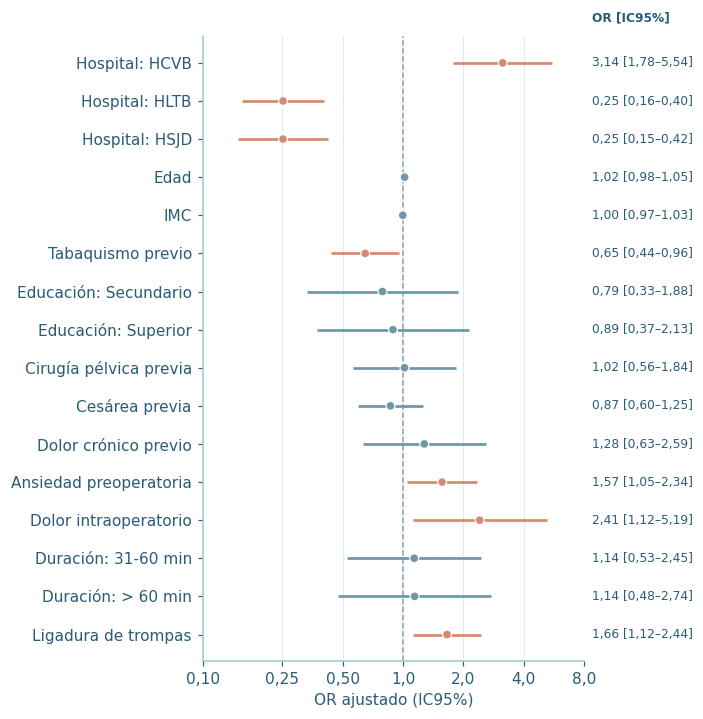

In [9]:
# Rótulos breves para los diagramas de bosque para ajustralos a la caja
ETIQUETA_FOREST = {
    "hads_a__Sí":                  "Ansiedad preoperatoria",
    "d_io__Sí":                    "Dolor intraoperatorio",
    "dc__Sí":                      "Dolor crónico previo",
    "tbq__Sí":                     "Tabaquismo previo",
    "amo_cxpp__Sí":                "Cirugía pélvica previa",
    "amo_cp__Sí":                  "Cesárea previa",
    "lig_trompas__Sí":             "Ligadura de trompas",
    "ne__Secundario":              "Educación: Secundario",
    "ne__Superior":                "Educación: Superior",
    "duracion_cesarea__31-60 min": "Duración: 31-60 min",
    "duracion_cesarea__> 60 min":  "Duración: > 60 min",
}

fig = rendern.forest(asoc, etiquetas=ETIQUETA_FOREST)
rendern.guardar(fig, "fig_forest_asociaciones")
fig


In [10]:
tabla_asociaciones = tabula.tabla_modelo_explicativo(asoc, catalogo)
tabula.construir_docx(
    tabla_asociaciones,
    tabula.Spec(config.TABLAS_MANUSCRITO["ME_modelo_explicativo"],
                "Factores asociados a dolor moderado a intenso en la primera semana postcesárea",
                nota=f"Regresión logística multivariable ajustada sobre n = {a['n']} "
                     f"({a['eventos']} eventos). Odds ratio con intervalo de confianza de Wald al "
                     "95 %. Nivel de referencia declarado junto a cada término. Faltantes "
                     "completados por mediana o moda. Valores p en negrita cuando p < 0,05.",
                grupo="Bloque"))

tabla_asociaciones

✔ tabla_ME_modelo_explicativo.docx  (16 filas)
✔ tabla_ME_modelo_explicativo.tex  (16 filas)


,Bloque,Predictor,OR ajustado,IC 95 %,p
1,Preoperatorio,Hospital: HCVB (ref: HCUCH),"3,14","1,78 – 5,54","< 0,001"
2,Preoperatorio,Hospital: HLTB (ref: HCUCH),"0,25","0,16 – 0,40","< 0,001"
3,Preoperatorio,Hospital: HSJD (ref: HCUCH),"0,25","0,15 – 0,42","< 0,001"
4,Preoperatorio,Edad,"1,02","0,98 – 1,05","0,294"
5,Preoperatorio,IMC,"1,00","0,97 – 1,03","0,826"
6,Preoperatorio,Tabaquismo previo al embarazo: Sí (ref: No),"0,65","0,44 – 0,96","0,028"
7,Preoperatorio,Nivel educacional: Secundario (ref: Primario),"0,79","0,33 – 1,88","0,593"
8,Preoperatorio,Nivel educacional: Superior (ref: Primario),"0,89","0,37 – 2,13","0,794"
9,Preoperatorio,Cirugía pélvica previa: Sí (ref: No),"1,02","0,56 – 1,84","0,957"
10,Preoperatorio,Cesárea previa: Sí (ref: No),"0,87","0,60 – 1,25","0,440"


## 4. Estabilidad de la selección

Se estima con qué frecuencia cada predictor candidato conserva un coeficiente no nulo al remuestrear
bajo penalización LASSO, eligiendo la penalización por validación interna en cada remuestra.

El criterio queda subordinado al clínico: puede respaldar la incorporación de un predictor no
previsto, pero no excluir un factor de riesgo reportado en la literatura.

In [11]:

candidatos = modell.predictores(catalogo, "periop", "con_centro")
estabilidad = modell.estabilidad_seleccion(cohorte, candidatos, catalogo)

print(f"estables (≥ {config.ESTABILIDAD_UMBRAL:.2f}): {int(estabilidad['estable'].sum())} "
      f"de {len(estabilidad)}")
estabilidad.head(15)

estables (≥ 0.60): 16 de 39


,var_rename,label,frecuencia,signo,consistencia_signo,estabilidad,estable
0,edad,Edad,1.00,positivo,1.0,fuerte,True
1,bupi_it,Bupivacaína intratecal,1.00,negativo,1.0,fuerte,True
2,paracetamol_24h,Paracetamol postoperatorio,1.00,negativo,1.0,fuerte,True
3,nauseas_io,Nausea Intraoperatoria,1.00,positivo,1.0,fuerte,True
4,lig_trompas,Ligadura de trompas,1.00,positivo,1.0,fuerte,True
5,morf_it,Morfina intratecal,1.00,positivo,1.0,fuerte,True
6,hosp,Hospital,1.00,positivo,1.0,fuerte,True
7,eg,Edad gestacional (semanas),1.00,negativo,1.0,fuerte,True
8,an_paracetamol,Paracetamol intraoperatorio,0.98,negativo,1.0,fuerte,True
9,tbq,Tabaquismo previo al embarazo,0.94,negativo,1.0,fuerte,True


In [12]:
tabula.construir_docx(
    tabula.tabla_estabilidad(estabilidad),
    tabula.Spec(config.TABLAS_MANUSCRITO["ES_estabilidad"],
                "Anexo. Estabilidad de la selección de variables bajo remuestreo penalizado",
                nota=f"Validación cruzada estratificada de {config.ESTABILIDAD_PARTICIONES} "
                     f"particiones repetida {config.ESTABILIDAD_REPETICIONES} veces. En cada "
                     "remuestra la penalización se eligió por validación interna."))

✔ tabla_ES_estabilidad_seleccion.docx  (39 filas)
✔ tabla_ES_estabilidad_seleccion.tex  (39 filas)


In [13]:
# Anexo - apoyo a la selección de predictores
tipos = dict(zip(catalogo["var_rename"], catalogo["conceptual_type"]))
bivariado = pd.DataFrame([
    {"var_rename": v,
     "p": statistik.bivariado(cohorte[v], cohorte[config.OUTCOME],
                              statistik.resolver_tipo(cohorte[v], tipos.get(v, "nom")))["p"]}
    for v in estabilidad["var_rename"] if v in cohorte.columns])

_u = f"{config.ESTABILIDAD_UMBRAL:.2f}".replace(".", ",")
_uf = f"{config.ESTABILIDAD_UMBRAL_FUERTE:.2f}".replace(".", ",")

anexo_apoyo = tabula.tabla_apoyo_seleccion(bivariado, estabilidad, catalogo)
tabula.construir_docx(
    anexo_apoyo,
    tabula.Spec(config.TABLAS_MANUSCRITO["AS_apoyo_seleccion"],
                "Anexo. Comportamiento de cada predictor candidato en los criterios de apoyo a la "
                "selección",
                nota=f"p bivariado: asociación cruda con el desenlace principal. Frec. LASSO: "
                     f"proporción de remuestras en que la variable conserva coeficiente no nulo. "
                     f"Ambos criterios operan subordinados al criterio clínico. La estabilidad es "
                     f"fuerte cuando esa proporción alcanza o supera {_uf}, moderada entre {_u} y "
                     f"{_uf}, e inestable por debajo de {_u}.",
                grupo="Bloque",
                apaisada=True))

anexo_apoyo

✔ tabla_AS_apoyo_seleccion.docx  (39 filas)
✔ tabla_AS_apoyo_seleccion.tex  (39 filas)  → requiere apaisada en el anexo


,Bloque,Predictor,p bivariado,Frec. LASSO,Estabilidad
0,Preoperatorio,Edad,"0,051","1,00",Fuerte
6,Preoperatorio,Hospital,"< 0,001","1,00",Fuerte
7,Preoperatorio,Edad gestacional (semanas),"0,095","1,00",Fuerte
9,Preoperatorio,Tabaquismo previo al embarazo,"0,113","0,94",Fuerte
10,Preoperatorio,Ansiedad preoperatoria (HADS-A >=8),"0,001","0,94",Fuerte
17,Preoperatorio,Sindrome hipertensivo del embarazo,"0,605","0,52",Inestable
18,Preoperatorio,Nivel educacional,"0,225","0,52",Inestable
19,Preoperatorio,Depresión preoperatoria (HADS-D >=8),"0,009","0,52",Inestable
21,Preoperatorio,IMC,"0,958","0,48",Inestable
26,Preoperatorio,Diabetes,"0,105","0,36",Inestable


## 5. Especificaciones predictiva preoperatoria y perioperatoria

Las dos especificaciones que contrasta la hipótesis se construyen sobre el conjunto completo de
predictores candidatos, sin la selección clínica del arco de asociaciones. La preoperatoria se
restringe a la información disponible antes del procedimiento y la perioperatoria añade los bloques
intraoperatorio y postoperatorio temprano, de modo que la contiene.

El centro se excluye de ambas en el análisis principal, para no comprometer la transportabilidad
entre hospitales, y se reincorpora como escenario de sensibilidad.

In [14]:
datos = {}
for cohorte_nombre, marco in [("principal", cohorte), ("espinal", espinal)]:
    for especificacion in config.ESPECIFICACIONES:
        for escenario in config.ESCENARIOS:
            d = modell.preparar_datos(marco, catalogo, especificacion, escenario,
                                      cohorte=cohorte_nombre)
            datos[(cohorte_nombre, escenario, especificacion)] = d
            e = modell.epv(d)
            print(f"{cohorte_nombre:10s} {escenario:11s} {especificacion:7s} "
                  f"{d.X.shape[1]:2d} predictores · EPV {e['EPV']:5.2f} "
                  f"{'✔' if e['cumple'] else '⚠'}")

principal  sin_centro  preop   16 predictores · EPV 26.44 ✔
principal  con_centro  preop   17 predictores · EPV 24.88 ✔
principal  sin_centro  periop  38 predictores · EPV 11.13 ✔
principal  con_centro  periop  39 predictores · EPV 10.85 ✔
espinal    sin_centro  preop   15 predictores · EPV 27.40 ✔
espinal    con_centro  preop   16 predictores · EPV 25.69 ✔
espinal    sin_centro  periop  31 predictores · EPV 13.26 ✔
espinal    con_centro  periop  32 predictores · EPV 12.84 ✔


In [15]:
# Tabla y anexo - composiciónm de las especificaciones en cada cohorte. 
# sirve para las dos
especificaciones = {}
for clave, coh, titulo in [
    ("T4_especificaciones", "principal",
     "Tabla. Composición de las especificaciones preoperatoria y perioperatoria"),
    ("AX_especificaciones_esp", "espinal",
     "Anexo. Composición de las especificaciones en la subcohorte espinal")]:
    especificaciones[coh] = tabula.tabla_especificaciones(catalogo, modell.predictores, coh)
    tabula.construir_docx(
        especificaciones[coh],
        tabula.Spec(config.TABLAS_MANUSCRITO[clave], titulo,
                    nota="Ambas especificaciones excluyen la variable centro. La perioperatoria "
                         "contiene a la preoperatoria y añade los bloques intraoperatorio y "
                         "postoperatorio temprano.",
                    grupo="Bloque"))

display(especificaciones["principal"], especificaciones["espinal"])


✔ tabla_T4_especificaciones.docx  (38 filas)
✔ tabla_T4_especificaciones.tex  (38 filas)
✔ tabla_AX_especificaciones_espinal.docx  (31 filas)
✔ tabla_AX_especificaciones_espinal.tex  (31 filas)


,Bloque,Predictor,Preoperatoria,Perioperatoria
23,Preoperatorio,Ansiedad preoperatoria (HADS-A >=8),Sí,Sí
15,Preoperatorio,Antecedente de dolor crónico,Sí,Sí
0,Preoperatorio,Cesárea previa,Sí,Sí
1,Preoperatorio,Cirugía pélvica previa,Sí,Sí
11,Preoperatorio,Clasificación ASA,Sí,Sí
24,Preoperatorio,Depresión preoperatoria (HADS-D >=8),Sí,Sí
3,Preoperatorio,Diabetes,Sí,Sí
2,Preoperatorio,Distocia de posición,Sí,Sí
19,Preoperatorio,Edad,Sí,Sí
20,Preoperatorio,Edad gestacional (semanas),Sí,Sí


,Bloque,Predictor,Preoperatoria,Perioperatoria
17,Preoperatorio,Ansiedad preoperatoria (HADS-A >=8),Sí,Sí
11,Preoperatorio,Antecedente de dolor crónico,Sí,Sí
0,Preoperatorio,Cesárea previa,Sí,Sí
1,Preoperatorio,Cirugía pélvica previa,Sí,Sí
7,Preoperatorio,Clasificación ASA,Sí,Sí
18,Preoperatorio,Depresión preoperatoria (HADS-D >=8),Sí,Sí
3,Preoperatorio,Diabetes,Sí,Sí
2,Preoperatorio,Distocia de posición,Sí,Sí
13,Preoperatorio,Edad,Sí,Sí
14,Preoperatorio,Edad gestacional (semanas),Sí,Sí


In [16]:
# Anexo - eventos por parámetro
filas_epv = [{"modelo": "Multivariable de asociaciones", "n": a["n"],
              "n_parametros": a["n_parametros"] - 1, "eventos": a["eventos"],
              "EPV": a["eventos"] / (a["n_parametros"] - 1), "cumple": True}]
for especificacion in config.ESPECIFICACIONES:
    r = modell.epv(datos[("principal", "sin_centro", especificacion)])
    filas_epv.append({"modelo": config.NOMBRE_ESPECIFICACION[especificacion], **r,
                      "cumple": r["cumple"]})

anexo_epv = tabula.tabla_epv(filas_epv)
tabula.construir_docx(
    anexo_epv,
    tabula.Spec(config.TABLAS_MANUSCRITO["EP_eventos_por_parametro"],
                "Anexo. Eventos por parámetro de los modelos del análisis principal",
                nota=f"Criterio orientador de {config.EPV_MIN} eventos por parámetro. En el modelo "
                     "multivariable los parámetros corresponden a los términos expandidos."))

anexo_epv

✔ tabla_EP_eventos_por_parametro.docx  (3 filas)
✔ tabla_EP_eventos_por_parametro.tex  (3 filas)


,Modelo,n,Parámetros,Eventos,EPV,Cumple
0,Multivariable de asociaciones,714,16,423,"26,4",Sí
1,Preoperatoria,714,16,423,"26,4",Sí
2,Perioperatoria,714,38,423,"11,1",Sí


## 6. Entrenamiento y validación cruzada anidada

Cada combinación de cohorte, escenario y especificación se entrena bajo el mismo esquema anidado: un
bucle externo de diez pliegues estima el desempeño y uno interno de cinco selecciona los
hiperparámetros.

El preprocesamiento y la selección ocurren únicamente con los datos de entrenamiento de cada pliegue,
de modo que la predicción de cada paciente provenga de un modelo que no la incluyó. Cada combinación
se persiste al terminar, de modo que una interrupción no obligue a repetir las anteriores.

In [17]:

RUTA = config.OUTPUTS / "predictivo"

partes = {clave: evaluar.persistir(RUTA / f"oof_{clave[0]}_{clave[1]}_{clave[2]}.parquet",
                                   lambda d=d: modell.validar_cruzado(d))
          for clave, d in datos.items()}

oof = pd.concat(partes.values(), ignore_index=True)

# Concatenar descarta lo que cuelga de cada marco: los hiperparámetros elegidos por
# pliegue se recogen aparte, porque son el insumo del anexo correspondiente.
hiperparametros = pd.concat(
    [pd.DataFrame(p.attrs["hiperparametros"]).assign(cohorte=c, escenario=e, especificacion=s)
     for (c, e, s), p in partes.items() if p.attrs.get("hiperparametros")],
    ignore_index=True)

print(f"\n{oof.groupby(list(evaluar.CLAVES)).ngroups} combinaciones "
      f"· {len(oof):,} predicciones fuera de pliegue")

✔ recuperado oof_principal_sin_centro_preop.parquet
✔ recuperado oof_principal_con_centro_preop.parquet
✔ recuperado oof_principal_sin_centro_periop.parquet
✔ recuperado oof_principal_con_centro_periop.parquet
✔ recuperado oof_espinal_sin_centro_preop.parquet
✔ recuperado oof_espinal_con_centro_preop.parquet
✔ recuperado oof_espinal_sin_centro_periop.parquet
✔ recuperado oof_espinal_con_centro_periop.parquet

56 combinaciones · 39,312 predicciones fuera de pliegue


In [18]:
# Anexo · hiperparámetros. La selección ocurre dentro de cada pliegue externo, de modo que lo
# informativo no es un valor único sino en cuántos pliegues se eligió cada uno.
anexo_hiperparametros = tabula.tabla_hiperparametros( hiperparametros[hiperparametros["cohorte"].eq("principal") & hiperparametros["escenario"].eq("sin_centro")], config.GRILLAS)
tabula.construir_docx(
    anexo_hiperparametros,
    tabula.Spec(config.TABLAS_MANUSCRITO["AX_hiperparametros"],
                "Anexo. Hiperparámetros explorados y seleccionados por algoritmo",
                grupo="Especificación",
                nota="La selección ocurre por validación cruzada interna dentro de cada pliegue "
                     "externo, de modo que un algoritmo puede terminar con valores distintos según el "
                     "pliegue. Entre paréntesis, en cuántos pliegues se eligió cada valor."))

anexo_hiperparametros

✔ tabla_AX_hiperparametros.docx  (30 filas)
✔ tabla_AX_hiperparametros.tex  (30 filas)


,Especificación,Algoritmo,Hiperparámetro,Rejilla explorada,Elegidos por pliegue
0,Preoperatoria,LR,—,—,—
1,Preoperatoria,LASSO,C,"0,001, 0,01, 0,1, 1,0, 10,0","10,0 (6), 1,0 (4)"
2,Preoperatoria,ElasticNet,C,"0,01, 0,1, 1,0, 10,0","10,0 (7), 1,0 (2), 0,1 (1)"
3,Preoperatoria,ElasticNet,l1_ratio,"0,2, 0,5, 0,8","0,5 (4), 0,8 (3), 0,2 (3)"
4,Preoperatoria,RF,max_depth,"4, 6, None","4 (8), None (2)"
5,Preoperatoria,RF,min_samples_leaf,"10, 20","10 (6), 20 (4)"
6,Preoperatoria,RF,n_estimators,"200, 400","200 (7), 400 (3)"
7,Preoperatoria,GBM,learning_rate,"0,05, 0,1","0,1 (7), 0,05 (3)"
8,Preoperatoria,GBM,max_depth,"3, 4","3 (9), 4 (1)"
9,Preoperatoria,GBM,n_estimators,"100, 200","200 (5), 100 (5)"


## 7. Desempeño predictivo

El desempeño se calcula sobre el vector agrupado de predicciones fuera de pliegue: la discriminación
mediante el AUC-ROC, la calibración mediante su pendiente e intercepto, y el error global mediante el
puntaje de Brier.

Los intervalos provienen de un remuestreo estratificado. La misma extracción alimenta las
comparaciones posteriores, de modo que sus intervalos procedan de las mismas remuestras.

In [19]:
# Los pares que responden a la hipótesis (preoperatorio → perioperatorio) y los de la
# sensibilidad por centro se declaran juntos: una sola extracción alimenta ambos, de modo
# que sus intervalos provengan de las mismas remuestras.
principal = oof[oof["cohorte"].eq("principal")]
pares_hipotesis = evaluar.pares_por_especificacion(principal)
pares_centro = evaluar.pares_por_escenario(principal)

extraccion = evaluar.remuestrear(principal, pares_hipotesis + pares_centro)
desempeno = evaluar.desempeno(principal, extraccion)

desempeno[desempeno["escenario"].eq("sin_centro")][
    ["especificacion", "algoritmo", "auc", "auc_ic_low", "auc_ic_high",
     "pendiente", "brier"]].round(3)

···················· ✔ 1000 remuestras sobre 28 combinaciones


,especificacion,algoritmo,auc,auc_ic_low,auc_ic_high,pendiente,brier
14,periop,ElasticNet,0.707,0.668,0.743,0.752,0.213
15,periop,GBM,0.706,0.667,0.743,0.628,0.215
16,periop,LASSO,0.717,0.676,0.753,0.752,0.210
17,periop,LR,0.711,0.670,0.746,0.647,0.213
18,periop,RF,0.742,0.706,0.775,1.616,0.205
19,periop,SVM,0.748,0.711,0.783,0.995,0.198
20,periop,XGB,0.720,0.681,0.757,0.757,0.208
21,preop,ElasticNet,0.586,0.542,0.627,0.563,0.239
22,preop,GBM,0.568,0.524,0.609,0.226,0.256
23,preop,LASSO,0.581,0.537,0.624,0.523,0.240


In [20]:
# Tabla · desempeño de los siete algoritmos en ambas especificaciones
tabla_desempeno = tabula.tabla_desempeno(desempeno)
tabula.construir_docx(
    tabla_desempeno,
    tabula.Spec(config.TABLAS_MANUSCRITO["PM_desempeno"],
                "Tabla. Desempeño predictivo por algoritmo y especificación",
                nota="Métricas calculadas sobre el vector agrupado de predicciones fuera de pliegue "
                     "(\\cref{sec:metricas-evaluacion}). Intervalos por remuestreo estratificado de "
                     "1000 remuestras. Una pendiente de calibración menor que uno indica estimaciones "
                     "extremas. Especificaciones sin la variable centro.",
                grupo="Especificación"))

tabla_desempeno

✔ tabla_PM_desempeno.docx  (14 filas)
✔ tabla_PM_desempeno.tex  (14 filas)


,Especificación,Algoritmo,AUC-ROC (IC95 %),Brier,Pendiente de calibración,Calibración media
19,Perioperatoria,SVM,"0,748 (0,711 – 0,783)","0,198","0,99","-0,013"
18,Perioperatoria,RF,"0,742 (0,706 – 0,775)","0,205","1,62","0,007"
20,Perioperatoria,XGB,"0,720 (0,681 – 0,757)","0,208","0,76","-0,005"
16,Perioperatoria,LASSO,"0,717 (0,676 – 0,753)","0,210","0,75","0,008"
17,Perioperatoria,LR,"0,711 (0,670 – 0,746)","0,213","0,65","0,003"
14,Perioperatoria,ElasticNet,"0,707 (0,668 – 0,743)","0,213","0,75","0,001"
15,Perioperatoria,GBM,"0,706 (0,667 – 0,743)","0,215","0,63","-0,021"
21,Preoperatoria,ElasticNet,"0,586 (0,542 – 0,627)","0,239","0,56","-0,002"
24,Preoperatoria,LR,"0,583 (0,538 – 0,624)","0,240","0,50","-0,001"
23,Preoperatoria,LASSO,"0,581 (0,537 – 0,624)","0,240","0,52","0,001"


✔ fig_roc_principal.png · fig_roc_principal.svg


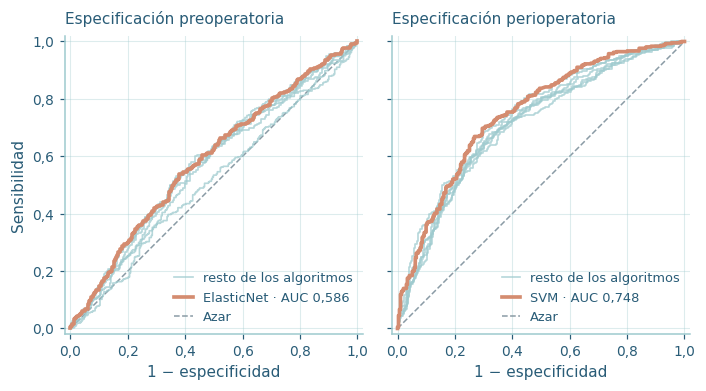

In [21]:
ETIQUETA = dict(zip(catalogo["var_rename"], catalogo["label"]))
sin_centro = principal[principal["escenario"].eq("sin_centro")]

fig = rendern.curvas_roc(sin_centro,
                         {"preop": "Especificación preoperatoria",
                          "periop": "Especificación perioperatoria"},
                         orden=list(config.ESPECIFICACIONES))
rendern.guardar(fig, "fig_roc_principal", dpi=450)
fig

## 8. Valor añadido de la información perioperatoria

Es la comparación que responde a la hipótesis. Cada algoritmo se compara consigo mismo entre ambas
especificaciones, sobre las mismas pacientes en cada remuestra, de modo que la diferencia no arrastre
variabilidad entre muestras.

El valor p es unilateral y corresponde a la proporción de remuestras en que la diferencia no favoreció
a la especificación perioperatoria.

In [22]:
pareada = evaluar.comparacion_pareada(principal, pares_hipotesis, extraccion)

print(f"ΔAUC entre {pareada['delta_auc'].min():.3f} y {pareada['delta_auc'].max():.3f} "
      f"· significativas: {int((pareada['p_unilateral'] < 0.05).sum())} de {len(pareada)}")
pareada[["referencia", "alternativa", "delta_auc", "delta_auc_ic_low",
         "delta_auc_ic_high", "p_unilateral"]].round(4)

ΔAUC entre 0.011 y 0.238 · significativas: 13 de 14


,referencia,alternativa,delta_auc,delta_auc_ic_low,delta_auc_ic_high,p_unilateral
0,principal · sin_centro · preop · LR,principal · sin_centro · periop · LR,0.1275,0.0829,0.1694,0.000
1,principal · sin_centro · preop · LASSO,principal · sin_centro · periop · LASSO,0.1353,0.0900,0.1792,0.000
2,principal · sin_centro · preop · ElasticNet,principal · sin_centro · periop · ElasticNet,0.1213,0.0777,0.1651,0.000
3,principal · sin_centro · preop · RF,principal · sin_centro · periop · RF,0.1771,0.1329,0.2212,0.000
4,principal · sin_centro · preop · GBM,principal · sin_centro · periop · GBM,0.1387,0.0960,0.1837,0.000
5,principal · sin_centro · preop · SVM,principal · sin_centro · periop · SVM,0.2382,0.1872,0.2852,0.000
6,principal · sin_centro · preop · XGB,principal · sin_centro · periop · XGB,0.1537,0.1076,0.2010,0.000
7,principal · con_centro · preop · LR,principal · con_centro · periop · LR,0.0108,-0.0108,0.0326,0.129
8,principal · con_centro · preop · LASSO,principal · con_centro · periop · LASSO,0.0252,0.0031,0.0459,0.010
9,principal · con_centro · preop · ElasticNet,principal · con_centro · periop · ElasticNet,0.0218,0.0034,0.0402,0.007


✔ fig_valor_anadido.png · fig_valor_anadido.svg


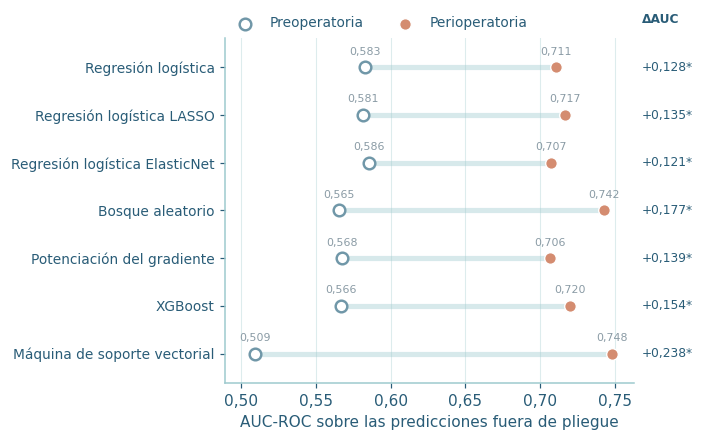

In [23]:
fig = rendern.valor_anadido(pareada[pareada["referencia"].str.contains("sin_centro")])
rendern.guardar(fig, "fig_valor_anadido", dpi=450)
fig

In [24]:
# Anexo · diferencia pareada entre especificaciones, por algoritmo
#
# `pareada` trae los catorce contrastes: los siete del escenario sin centro y los siete del
# escenario con centro. Sin declarar el escenario, las dos series de filas quedan idénticas
# en todo salvo en las cifras y el lector ve la misma regresión logística dos veces sin poder
# saber por qué difieren. Se declara como `grupo`, que lo convierte en banda de sección.
ETIQUETA_CONTRASTE = {r: "Perioperatoria frente a preoperatoria"
                      for r in pareada["referencia"].unique()}
ETIQUETA_ESCENARIO = {"sin_centro": "Sin la variable centro",
                      "con_centro": "Con la variable centro"}

anexo_pareada = tabula.tabla_pareada(pareada, etiquetas=ETIQUETA_CONTRASTE, escenarios=ETIQUETA_ESCENARIO)
tabula.construir_docx(
    anexo_pareada,
    tabula.Spec(config.TABLAS_MANUSCRITO["PareadaMaestra"],
                "Anexo. Valor añadido de la información perioperatoria por algoritmo",
                nota="Cada algoritmo se compara consigo mismo sobre las mismas pacientes en cada "
                     "remuestra (\\cref{sec:comparacion-pareada-preoperatorio-perioperatorio}), de "
                     "modo que la diferencia no arrastre variabilidad entre muestras. El valor p es "
                     "unilateral y corresponde a la proporción de remuestras en que la diferencia no "
                     "favoreció a la especificación perioperatoria. Un ΔBrier negativo indica mejora.",
                grupo="Escenario",
                apaisada=True))

anexo_pareada

✔ tabla_PareadaMaestra.docx  (14 filas)
✔ tabla_PareadaMaestra.tex  (14 filas)  → requiere apaisada en el anexo


,Escenario,Contraste,Algoritmo,ΔAUC-ROC (IC95 %),p,ΔBrier (IC95 %),p
0,Sin la variable centro,Perioperatoria frente a preoperatoria,LR,"0,128 (0,083 a 0,169)","< 0,001","-0,027 (-0,039 a -0,013)","< 0,001"
1,Sin la variable centro,Perioperatoria frente a preoperatoria,LASSO,"0,135 (0,090 a 0,179)","< 0,001","-0,030 (-0,042 a -0,017)","< 0,001"
2,Sin la variable centro,Perioperatoria frente a preoperatoria,ElasticNet,"0,121 (0,078 a 0,165)","< 0,001","-0,025 (-0,037 a -0,013)","< 0,001"
3,Sin la variable centro,Perioperatoria frente a preoperatoria,RF,"0,177 (0,133 a 0,221)","< 0,001","-0,034 (-0,041 a -0,026)","< 0,001"
4,Sin la variable centro,Perioperatoria frente a preoperatoria,GBM,"0,139 (0,096 a 0,184)","< 0,001","-0,041 (-0,057 a -0,025)","< 0,001"
5,Sin la variable centro,Perioperatoria frente a preoperatoria,SVM,"0,238 (0,187 a 0,285)","< 0,001","-0,046 (-0,058 a -0,033)","< 0,001"
6,Sin la variable centro,Perioperatoria frente a preoperatoria,XGB,"0,154 (0,108 a 0,201)","< 0,001","-0,047 (-0,063 a -0,031)","< 0,001"
7,Con la variable centro,Perioperatoria frente a preoperatoria,LR,"0,011 (-0,011 a 0,033)","0,129","-0,003 (-0,012 a 0,007)","0,237"
8,Con la variable centro,Perioperatoria frente a preoperatoria,LASSO,"0,025 (0,003 a 0,046)","0,010","-0,007 (-0,014 a 0,001)","0,047"
9,Con la variable centro,Perioperatoria frente a preoperatoria,ElasticNet,"0,022 (0,003 a 0,040)","0,007","-0,005 (-0,010 a 0,000)","0,029"


## 9. Interpretabilidad

La importancia por permutación se calcula en los siete algoritmos y se resume como un consenso de
rangos, que evita hacer depender la lectura de un único modelo. Los valores SHAP se calculan sobre el
bosque aleatorio, donde el cálculo es exacto y no una aproximación, y describen la forma de cada
relación además de su peso.

La interpretabilidad describe qué información sustenta la predicción. No constituye un listado de
factores de riesgo ni admite lectura causal.

In [25]:
# Permutación en los siete algoritmos de la especificación perioperatoria.
#
# Tamaño del conjunto de interpretabilidad de cada cohorte, común a su figura de consenso, a
# su tabla logística y a sus paneles SHAP: los tres instrumentos se refieren exactamente al
# mismo conjunto. Coincide con el umbral que `evaluar.consenso` usa para su columna
# n_modelos_topN, de modo que la figura no informe pertenencia a un top del que sus últimas
# filas están fuera.
TOP_CONSENSO = 10
COLUMNA_CONSENSO = f"n_modelos_top{TOP_CONSENSO}"   # derivada: fijarla la desincroniza

# Criterio de selección de los paneles de dependencia SHAP, común a ambas cohortes:
#   "consenso" solo el top TOP_CONSENSO del consenso (por defecto)
#   "union"    ese top junto al top por |SHAP| medio del bosque
#   "shap"     solo el top del bosque
# Las tres se conservan para reproducir versiones anteriores de la figura.
CRITERIO_PANELES_SHAP = "consenso"

periop = datos[("principal", "sin_centro", "periop")]

permutacion = evaluar.persistir(
    RUTA / "permutacion_principal_periop.parquet",
    lambda: evaluar.importancia_permutacion(periop))

consenso = evaluar.consenso(permutacion, top=TOP_CONSENSO)
consenso.head(TOP_CONSENSO)[["var_rename", "rango_medio", "rango_de", COLUMNA_CONSENSO]].round(2)

✔ recuperado permutacion_principal_periop.parquet


,var_rename,rango_medio,rango_de,n_modelos_top10
0,morf_it,2.29,0.95,7
1,paracetamol_24h,2.29,3.40,7
2,nauseas_io,5.57,3.78,6
3,edad,6.43,3.87,6
4,bupi_it,9.57,5.00,4
5,an_ketorolaco,9.71,2.21,4
6,lig_trompas,11.57,2.30,3
7,hipotension_io,12.14,7.76,4
8,oxitoc_rtx_bolo,12.14,4.22,4
9,an_paracetamol,12.29,10.75,5


✔ fig_consenso_permutacion.png · fig_consenso_permutacion.svg


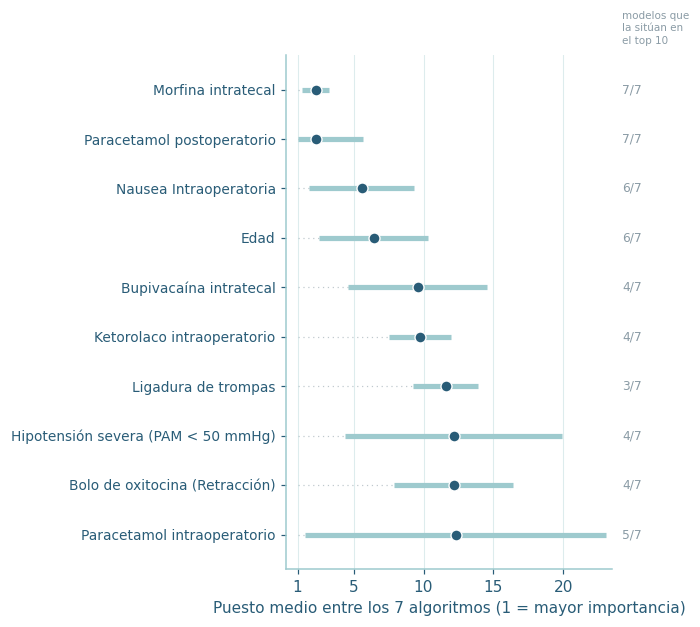

In [26]:
fig = rendern.consenso_permutacion(
    consenso, etiquetas=ETIQUETA, top=TOP_CONSENSO, columna=COLUMNA_CONSENSO)
rendern.guardar(fig, "fig_consenso_permutacion")
fig

In [27]:
# Valores SHAP del modelo de árboles sobre la misma especificación
shap = evaluar.persistir(
    RUTA / "shap_principal_periop.parquet",
    lambda: evaluar.shap_valores(periop))

(shap.groupby("columna")["shap"].apply(lambda s: s.abs().mean())
 .sort_values(ascending=False).head(10).round(4))

✔ recuperado shap_principal_periop.parquet


columna
paracetamol_24h    0.0574
an_paracetamol     0.0306
an_dipirona        0.0229
nauseas_io         0.0217
morf_it            0.0195
edad               0.0186
lig_trompas        0.0155
hads_a             0.0119
ne                 0.0112
imc                0.0106
Name: shap, dtype: float64

✔ fig_dependencia_shap.png · fig_dependencia_shap.svg


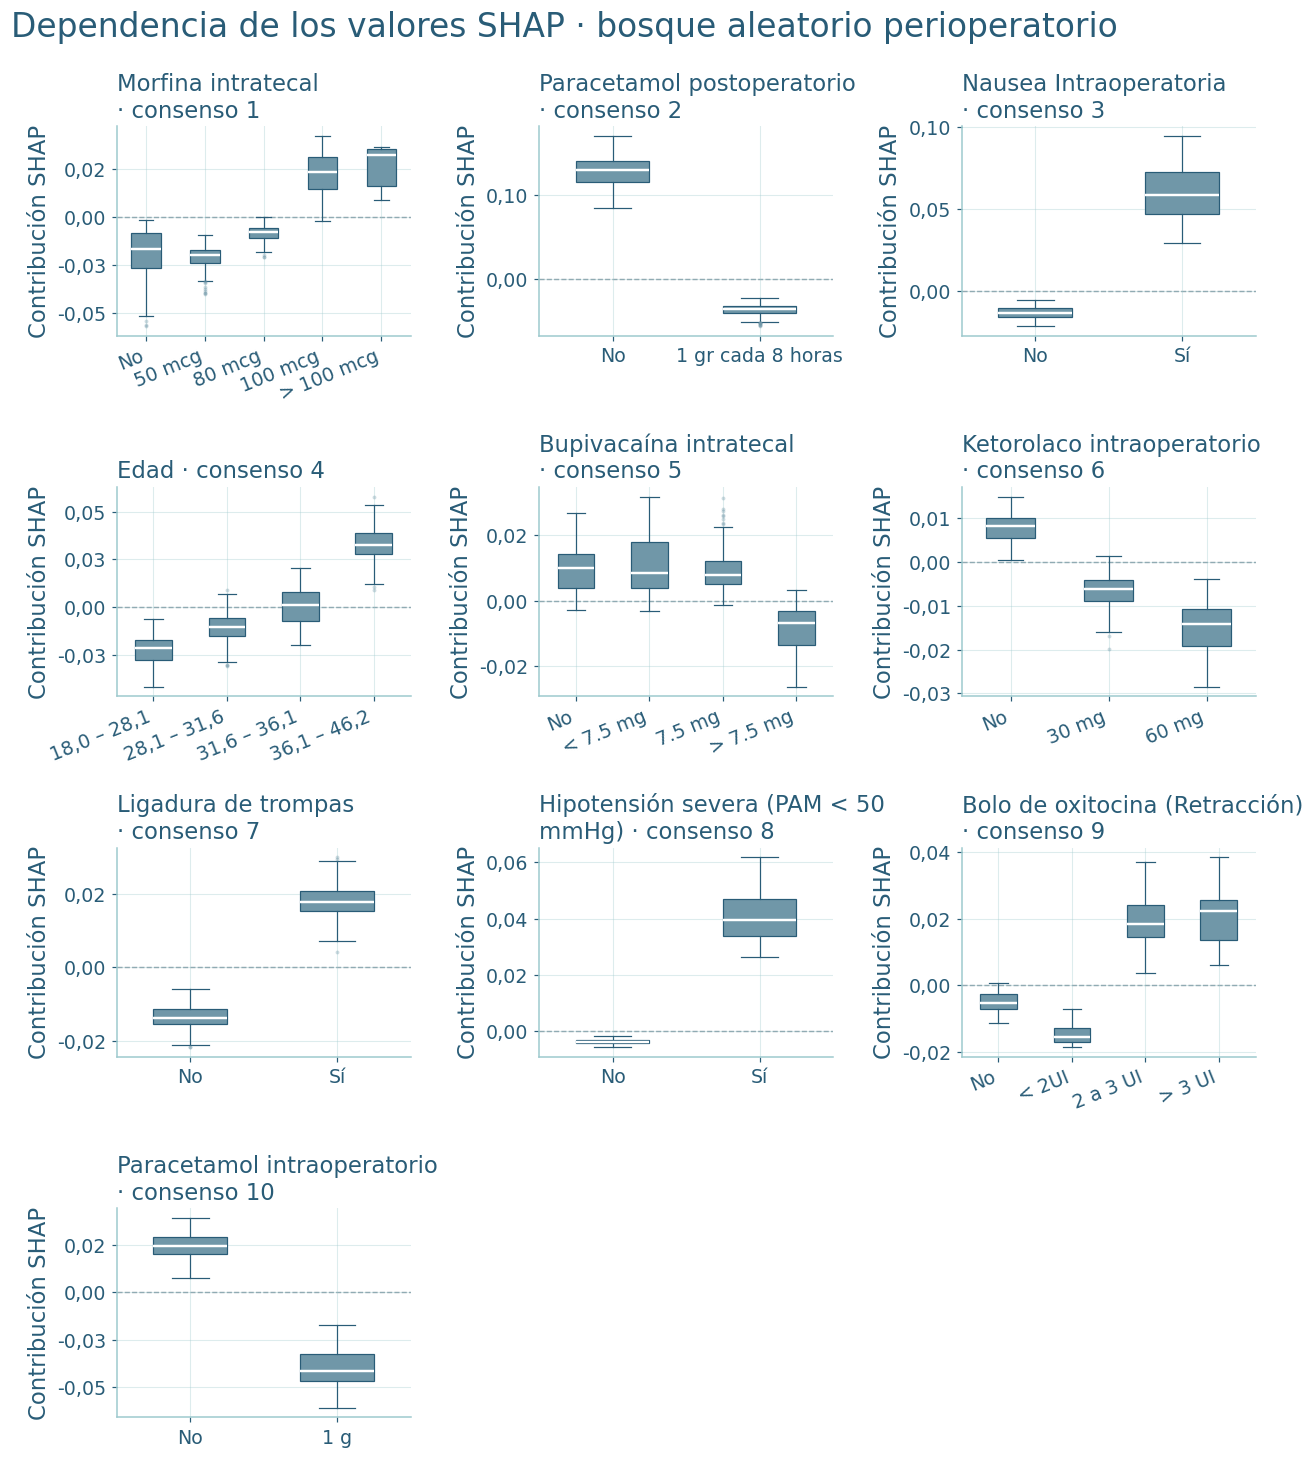

,var_rename,puesto,rango_medio,shap_abs_medio,criterio
0,morf_it,1,2.285714,0.019530,ambos
1,paracetamol_24h,2,2.285714,0.057440,ambos
2,nauseas_io,3,5.571429,0.021672,ambos
3,edad,4,6.428571,0.018601,ambos
4,bupi_it,5,9.571429,0.009176,consenso
5,an_ketorolaco,6,9.714286,0.009287,consenso
6,lig_trompas,7,11.571429,0.015523,ambos
7,hipotension_io,8,12.142857,0.006998,consenso
8,oxitoc_rtx_bolo,9,12.142857,0.009267,consenso
9,an_paracetamol,10,12.285714,0.030611,ambos


In [28]:
# Qué predictores reciben panel. Son los mismos TOP_CONSENSO del consenso que dibuja la
# figura anterior y que ocupan las filas de la tabla logística de esta cohorte, de modo que
# los tres instrumentos se lean fila a fila. El título de cada panel indica el puesto que el
# consenso le asigna, ver `evaluar.paneles_shap`.
paneles = evaluar.paneles_shap(consenso, shap, criterio=CRITERIO_PANELES_SHAP,
                               top=TOP_CONSENSO)
columnas_shap = paneles["var_rename"].tolist()

# Tipo y orden de nivel de cada predictor, para que el eje respete la escala clínica en vez
# de la preprocesada: "num" se agrupa en tramos de percentil, el resto muestra sus niveles
# originales en el orden que declara el catálogo.
tipos_shap = dict(zip(catalogo["var_rename"], catalogo["conceptual_type"]))
niveles_shap = {v: modell.niveles_declarados(catalogo, v, cohorte[v] if v in cohorte.columns else None)
               for v in columnas_shap}

fig = rendern.dependencia_shap(shap, columnas_shap,
                             "Dependencia de los valores SHAP · bosque aleatorio perioperatorio",
                             etiquetas=ETIQUETA, tipos=tipos_shap, niveles=niveles_shap,
                             rangos=dict(zip(paneles["var_rename"], paneles["puesto"])),
                             ncols=3)
rendern.guardar(fig, "fig_dependencia_shap")
display(fig)

paneles

## 10. Sensibilidad y robustez

Los análisis de esta sección son exploratorios y no responden a los objetivos específicos. Examinan
si los resultados dependen de la definición del desenlace, de la técnica anestésica, de la inclusión
del centro como predictor o del hospital en que se entrena cada modelo.

### 10.1 Consistencia entre operacionalizaciones del desenlace

El mismo conjunto de covariables se reajusta sobre las definiciones secundarias del desenlace, con la
familia que corresponde a la escala de cada una: logística para las binarias, ordinal de razones
proporcionales para la severidad y lineal robusta para la intensidad máxima.

Interesa si la dirección y la señal de cada término se mantienen entre definiciones, o si dependen de
la forma en que se operacionalizó el dolor.

In [29]:
DESENLACES = {"dmg_1s_bin": "logit", "dolor_grave": "logit", "dmg_24h": "logit",
              "dmg_48h": "logit", "dmg_7d": "logit",
              "severidad": "ordinal", "dmax_1s": "lineal"}
ETIQUETA_DESENLACE = {"dmg_1s_bin": "1ª semana", "dolor_grave": "Dolor intenso",
                      "dmg_24h": "24 h", "dmg_48h": "48 h", "dmg_7d": "7º día",
                      "severidad": "Severidad", "dmax_1s": "Intensidad máx. (β)"}

# Un ajuste por definición, con la familia que corresponde a su escala.
ajustes = {d: modell.ajustar(cohorte, asociativa, catalogo, d, familia=f)
           for d, f in DESENLACES.items()}

consistencia = modell.clasificar_consistencia(
    modell.consistencia(cohorte, asociativa, catalogo, DESENLACES),
    temprano=("dmg_24h",), tardio=("dmg_7d",), gravedad=("dolor_grave", "severidad"))

(consistencia.groupby(["var_rename", "label"], as_index=False)
 .agg(senales=("n_desenlaces_con_senal", "first"),
      consistente=("direccion_consistente", "first"),
      clasificacion=("clasificacion", "first"))
 .sort_values("senales", ascending=False))

,var_rename,label,senales,consistente,clasificacion
8,hosp,Hospital: HCVB (ref: HCUCH),7,False,asociado_gravedad
9,hosp,Hospital: HLTB (ref: HCUCH),7,False,asociado_gravedad
7,hads_a,Ansiedad preoperatoria (HADS-A >=8): Sí (ref: No),6,True,consistente_global
2,d_io,Presencia de dolor intraoperatorio: Sí (ref: No),5,True,consistente_global
14,tbq,Tabaquismo previo al embarazo: Sí (ref: No),2,False,asociacion_inestable
3,dc,Antecedente de dolor crónico: Sí (ref: No),1,False,exploratorio
6,edad,Edad,1,False,asociado_dolor_tardio
11,lig_trompas,Ligadura de trompas: Sí (ref: No),1,False,exploratorio
12,ne,Nivel educacional: Secundario (ref: Primario),1,False,asociado_dolor_temprano
13,ne,Nivel educacional: Superior (ref: Primario),1,False,asociado_dolor_temprano


✔ fig_consistencia_principal.png · fig_consistencia_principal.svg


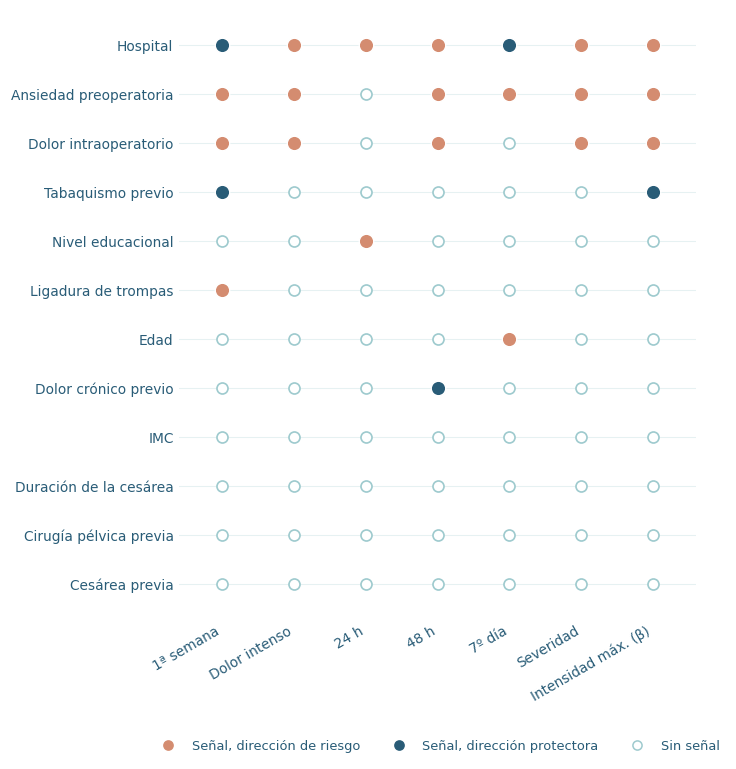

In [30]:
# Rótulos breves para las matrices de consistencia. El ancho de la columna de etiquetas
# decide cuánto se reduce la figura al ajustarla a la página, de modo que acortarlos es lo
# que la vuelve legible: con los nombres completos el cuerpo caía a 4,8 pt en el papel.
ETIQUETA_CONSISTENCIA = {
    "pnv_multi":        "Profilaxis antiemética múltiple",
    "an_multimodal_no": "Analgesia no opioide",
    "morf_bin":         "Morfina intratecal",
    "hads_a":           "Ansiedad preoperatoria",
    "d_io":             "Dolor intraoperatorio",
    "tbq":              "Tabaquismo previo",
    "dc":               "Dolor crónico previo",
    "duracion_cesarea": "Duración de la cesárea",
    "ne":               "Nivel educacional",
}

fig = rendern.consistencia(consistencia, etiquetas=ETIQUETA_DESENLACE,
                           etiquetas_var=ETIQUETA_CONSISTENCIA)
rendern.guardar(fig, "fig_consistencia_principal")
fig

In [31]:
# Anexo · estimaciones bajo cada definición del desenlace
anexo_desenlaces = tabula.tabla_por_desenlace(ajustes, catalogo, etiquetas=ETIQUETA_DESENLACE)
tabula.construir_docx(
    anexo_desenlaces,
    tabula.Spec(config.TABLAS_MANUSCRITO["DS_desenlaces_secundarios"],
                "Anexo. Estimaciones del modelo multivariable bajo cada definición del desenlace",
                nota="Odds ratio con intervalo de confianza al 95 %, salvo la última columna, que "
                     "reporta el coeficiente de un modelo lineal robusto. Severidad: modelo ordinal "
                     "de razones proporcionales. El asterisco marca p < 0,05. Mismo conjunto de "
                     "covariables en las siete definiciones.",
                grupo="Bloque",
                apaisada=True))

anexo_desenlaces

✔ tabla_DS_desenlaces_secundarios.docx  (16 filas)
✔ tabla_DS_desenlaces_secundarios.tex  (16 filas)  → requiere apaisada en el anexo


,Bloque,Predictor,1ª semana,Dolor intenso,24 h,48 h,7º día,Severidad,Intensidad máx. (β)
0,Preoperatorio,Hospital: HCVB (ref: HCUCH),"3,14 [1,78–5,54]*","4,94 [2,77–8,79]*","12,02 [7,04–20,53]*","7,32 [4,19–12,79]*","0,72 [0,46–1,14]","3,47 [2,26–5,34]*","1,53 [1,12–1,95]*"
1,Preoperatorio,Hospital: HLTB (ref: HCUCH),"0,25 [0,16–0,40]*","0,59 [0,29–1,23]","1,94 [1,15–3,29]*","0,82 [0,43–1,57]","0,08 [0,04–0,14]*","0,30 [0,19–0,46]*","-1,17 [-1,58–-0,76]*"
2,Preoperatorio,Hospital: HSJD (ref: HCUCH),"0,25 [0,15–0,42]*","0,48 [0,21–1,13]","0,27 [0,12–0,60]*","0,13 [0,04–0,44]*","0,39 [0,24–0,65]*","0,30 [0,19–0,48]*","-1,12 [-1,57–-0,68]*"
3,Preoperatorio,Edad,"1,02 [0,98–1,05]","1,03 [0,99–1,07]","0,99 [0,95–1,02]","1,02 [0,98–1,06]","1,04 [1,01–1,08]*","1,02 [0,99–1,05]","0,02 [-0,00–0,05]"
4,Preoperatorio,IMC,"1,00 [0,97–1,03]","0,99 [0,96–1,03]","1,01 [0,98–1,04]","0,99 [0,96–1,03]","1,01 [0,98–1,04]","1,00 [0,97–1,02]","-0,00 [-0,02–0,02]"
5,Preoperatorio,Tabaquismo previo al embarazo: Sí (ref: No),"0,65 [0,44–0,96]*","0,90 [0,55–1,46]","0,72 [0,47–1,10]","0,71 [0,44–1,16]","1,07 [0,73–1,57]","0,76 [0,54–1,06]","-0,33 [-0,64–-0,01]*"
6,Preoperatorio,Nivel educacional: Secundario (ref: Primario),"0,79 [0,33–1,88]","1,36 [0,51–3,63]","2,88 [1,16–7,11]*","2,04 [0,76–5,47]","0,53 [0,24–1,16]","0,98 [0,49–1,95]","0,12 [-0,54–0,79]"
7,Preoperatorio,Nivel educacional: Superior (ref: Primario),"0,89 [0,37–2,13]","1,41 [0,53–3,76]","2,06 [0,83–5,10]","2,00 [0,75–5,37]","0,67 [0,31–1,47]","1,06 [0,53–2,12]","0,22 [-0,44–0,89]"
8,Preoperatorio,Cirugía pélvica previa: Sí (ref: No),"1,02 [0,56–1,84]","1,18 [0,64–2,18]","0,92 [0,51–1,68]","1,13 [0,61–2,11]","0,94 [0,56–1,59]","1,08 [0,67–1,74]","0,17 [-0,29–0,63]"
9,Preoperatorio,Cesárea previa: Sí (ref: No),"0,87 [0,60–1,25]","0,85 [0,54–1,35]","1,05 [0,70–1,58]","1,15 [0,73–1,81]","0,74 [0,51–1,06]","0,84 [0,61–1,16]","-0,22 [-0,53–0,08]"


### 10.2 Subcohorte espinal · modelos anidados

Sobre la subcohorte espinal se incorpora al conjunto base, uno a la vez, cada bloque de variables
recodificadas del manejo anestésico. Cada peldaño se contrasta con el modelo base mediante una razón
de verosimilitud, y se registra el desplazamiento que produce en las estimaciones ya presentes.

Se examina además si la asociación de la morfina intratecal depende de algún centro en particular.

In [32]:
# Tabla · recodificaciones de la subcohorte espinal
CONVERSIONES = [
    {"var_rename": "morf_bin", "origen": "morf_it", "uso": "Escalera de modelos",
     "regla": "Presencia del fármaco, cualquier dosis frente a su ausencia"},
    {"var_rename": "morf_rec", "origen": "morf_it", "uso": "Predictivo, PeriOp",
     "regla": "Dosis agrupada en tres tramos, sin morfina, de 50 a 80 mcg, y 100 mcg o más. "
              "La escala original tiene niveles con muy pocos casos"},
    {"var_rename": "an_multimodal_no",
     "origen": "an_dipirona, an_ketoprofeno, an_ketorolaco, an_paracetamol",
     "uso": "Escalera de modelos y predictivo, PeriOp",
     "regla": "Recuento de agentes administrados de forma simultánea. Cero y uno se agrupan "
              "como menos de dos. Los dos antiinflamatorios son una sola clase farmacológica. "
              "Excluye la morfina por diseño"},
    {"var_rename": "pnv_multi", "origen": "dexa_pnv, ondan_pnv, drope_pnv",
     "uso": "Escalera de modelos y predictivo, PeriOp",
     "regla": "Dos o más antieméticos administrados de forma simultánea"},
    {"var_rename": "pnv_combo", "origen": "dexa_pnv, ondan_pnv, drope_pnv",
     "uso": "Escalera de modelos",
     "regla": "Composición según incluya o no dexametasona"},
    {"var_rename": "bundle_guia", "origen": "morf_bin, an_multimodal_no, pnv_multi",
     "uso": "Escalera de modelos",
     "regla": "Administración conjunta de los tres componentes, morfina intratecal, dos o más "
              "analgésicos no opioides y dos o más antieméticos"},
]

tabla_recodificaciones = tabula.tabla_conversiones(espinal, catalogo, CONVERSIONES)
tabula.construir_docx(
    tabla_recodificaciones,
    tabula.Spec(config.TABLAS_MANUSCRITO["RC_recodificaciones"],
                "Tabla. Variables recodificadas en la subcohorte espinal",
                nota="Una fila con cualquier componente faltante queda como faltante, porque el "
                     "recuento exacto es ambiguo si se desconoce si un fármaco se administró. "
                     "La presencia y la dosis de morfina intratecal son la misma variable en dos "
                     "resoluciones y no coinciden en un mismo modelo. Distribución recontada sobre "
                     "la subcohorte."))

tabla_recodificaciones

✔ tabla_RC_recodificaciones_espinal.docx  (6 filas)
✔ tabla_RC_recodificaciones_espinal.tex  (6 filas)


,Recodificada,Variables de origen,Regla de conversión,Distribución observada,Análisis en que se emplea
0,Morfina intratecal (cualquier dosis),morf_it,"Presencia del fármaco, cualquier dosis frente ...","Sí 468, No 217, sin dato 5",Escalera de modelos
1,Morfina intratecal (dosis),morf_it,"Dosis agrupada en tres tramos, sin morfina, de...","No 217, 50 a 80 mcg 216, 100 mcg o más 252, si...","Predictivo, PeriOp"
2,Analgesia no opioide (número de agentes),"an_dipirona, an_ketoprofeno, an_ketorolaco, an...",Recuento de agentes administrados de forma sim...,"Menos de dos 38, 2 agentes 594, 3 agentes 52, ...","Escalera de modelos y predictivo, PeriOp"
3,Profilaxis antiemética múltiple (dos o más fár...,"dexa_pnv, ondan_pnv, drope_pnv",Dos o más antieméticos administrados de forma ...,"Sí 529, No 158, sin dato 3","Escalera de modelos y predictivo, PeriOp"
4,Combinación de profilaxis antiemética,"dexa_pnv, ondan_pnv, drope_pnv",Composición según incluya o no dexametasona,"Ninguno 31, Sin dexametasona 56, Dexametasona ...",Escalera de modelos
5,Esquema completo de manejo (tres componentes),"morf_bin, an_multimodal_no, pnv_multi",Administración conjunta de los tres componente...,"Sí 371, No 310, sin dato 9",Escalera de modelos


In [33]:
M0 = modell.Configuracion("M0", asociativa.covariables, "Conjunto del análisis principal")
ESCALERA = [
    M0,
    M0.mas("M1", "morf_bin",         "Morfina intratecal"),
    M0.mas("M2", "an_multimodal_no", "Analgesia multimodal no opioide"),
    M0.mas("M3", "bundle_guia",      "Administración conjunta de los tres componentes"),
    M0.mas("M4", ["morf_bin", "an_multimodal_no", "pnv_multi"], "Bloque anestésico completo"),
    M0.mas("M5", "pnv_combo",        "Composición de la profilaxis antiemética"),
]

escalera = modell.escalera(espinal, ESCALERA, catalogo)
escalera[["peldano", "descripcion", "n_parametros", "AIC", "EPV", "lrt", "gl", "p_lrt"]].round(4)

,peldano,descripcion,n_parametros,AIC,EPV,lrt,gl,p_lrt
0,M0,Conjunto del análisis principal,17,788.19,25.69,NaN,NaN,NaN
1,M1,Morfina intratecal,18,784.10,24.18,6.093,1.0,0.0136
2,M2,Analgesia multimodal no opioide,19,779.94,22.83,12.248,2.0,0.0022
3,M3,Administración conjunta de los tres componentes,18,788.64,24.18,1.551,1.0,0.2130
4,M4,Bloque anestésico completo,21,776.83,20.55,19.364,4.0,0.0007
5,M5,Composición de la profilaxis antiemética,20,794.03,21.63,0.158,3.0,0.9840


In [34]:
anexo_escalera = tabula.tabla_escalera(escalera)
tabula.construir_docx(
    anexo_escalera,
    tabula.Spec(config.TABLAS_MANUSCRITO["EC_escalera"],
                "Anexo. Modelos anidados del manejo anestésico en la subcohorte espinal",
                nota="Cada peldaño incorpora un bloque de covariables al modelo base. La razón de "
                     "verosimilitud contrasta cada peldaño con ese modelo. EPV: eventos por "
                     "parámetro. Análisis exploratorio."))

anexo_escalera

✔ tabla_EC_escalera_modelos.docx  (6 filas)
✔ tabla_EC_escalera_modelos.tex  (6 filas)


,Peldaño,Covariables incorporadas,Parámetros,EPV,Razón de verosimilitud (gl),p
0,M0,Conjunto del análisis principal,17,"25,7",,
1,M1,Morfina intratecal,18,"24,2","6,09 (1)","0,014"
2,M2,Analgesia multimodal no opioide,19,"22,8","12,25 (2)","0,002"
3,M3,Administración conjunta de los tres componentes,18,"24,2","1,55 (1)","0,213"
4,M4,Bloque anestésico completo,21,"20,6","19,36 (4)","< 0,001"
5,M5,Composición de la profilaxis antiemética,20,"21,6","0,16 (3)","0,984"


In [35]:
desplazamiento = modell.cambio_en_estimacion(espinal, ESCALERA, catalogo, contra="base")

print(f"desplazamientos ≥ {config.CAMBIO_ESTIMACION_UMBRAL:.0f} %: "
      f"{int(desplazamiento['desplazamiento_relevante'].sum())}")
(desplazamiento[desplazamiento["desplazamiento_relevante"]]
 .sort_values("cambio_pct", key=abs, ascending=False)
 [["peldano", "label", "OR_referencia", "OR_peldano", "cambio_pct"]])

desplazamientos ≥ 10 %: 13


,peldano,label,OR_referencia,OR_peldano,cambio_pct
48,M4,Hospital: HCVB (ref: HCUCH),2.950,5.438,84.37
0,M1,Hospital: HCVB (ref: HCUCH),2.950,4.437,50.43
16,M2,Hospital: HCVB (ref: HCUCH),2.950,3.720,26.10
32,M3,Hospital: HCVB (ref: HCUCH),2.950,3.685,24.94
49,M4,Hospital: HLTB (ref: HCUCH),0.239,0.296,24.04
2,M1,Hospital: HSJD (ref: HCUCH),0.237,0.273,15.10
1,M1,Hospital: HLTB (ref: HCUCH),0.239,0.271,13.67
34,M3,Hospital: HSJD (ref: HCUCH),0.237,0.268,12.97
55,M4,Nivel educacional: Superior (ref: Primario),0.926,1.038,12.16
50,M4,Hospital: HSJD (ref: HCUCH),0.237,0.265,11.80


In [36]:
# Dependencia de la asociación de la morfina respecto de cada centro
robustez = modell.dejar_centro_fuera(espinal, ESCALERA[1], catalogo, "morf_bin")
robustez[["centro_excluido", "n", "OR", "ic_low", "ic_high", "p", "cambio_pct"]].round(3)

,centro_excluido,n,OR,ic_low,ic_high,p,cambio_pct
0,Ninguno,690,1.819,1.118,2.958,0.016,0.00
1,HCUCH,525,1.955,1.186,3.221,0.009,7.48
2,HCVB,495,2.375,1.330,4.241,0.003,30.57
3,HLTB,507,1.083,0.583,2.010,0.801,-40.46
4,HSJD,543,1.879,1.026,3.441,0.041,3.30


In [37]:
# Tabla · indicación de morfina y frecuencia del desenlace por centro.
# Sostiene que la asociación de la morfina la produce el ajuste: el centro que menos morfina
# indica es el que más desenlace registra, de modo que ambas corren en direcciones opuestas.
morfina_centro = tabula.tabla_exposicion_desenlace_centro(
    espinal, "morf_bin",
    rotulos={"exposicion": "Indicación de morfina intratecal",
             "desenlace": "Frecuencia del desenlace"})

# El denominador es el total del centro, no los casos observados: es la convención que ya
# publica el análisis de la subcohorte espinal, y con faltantes en la exposición las dos
# difieren.
_na = morfina_centro.attrs["faltantes"]["exposicion"]

tabula.construir_docx(
    morfina_centro,
    tabula.Spec(config.TABLAS_MANUSCRITO["MC_morfina_centro"],
                "Indicación de morfina intratecal y frecuencia del desenlace por centro",
                nota=f"Subcohorte espinal, {len(espinal)} pacientes. El desenlace es el compuesto "
                     "de dolor moderado a intenso durante la primera semana. La indicación de "
                     "morfina corresponde a su administración intratecal en cualquier dosis frente "
                     "a su ausencia. Las proporciones se calculan sobre el total de cada centro, de "
                     f"modo que las {_na} pacientes sin registro de la indicación quedan en el "
                     "denominador y no en el numerador."))

morfina_centro


✔ tabla_MC_morfina_centro.docx  (5 filas)
✔ tabla_MC_morfina_centro.tex  (5 filas)


,Centro,n,Indicación de morfina intratecal,Frecuencia del desenlace
0,HCUCH,165,"163/165 (98,8 %)","117/165 (70,9 %)"
1,HCVB,195,"65/195 (33,3 %)","171/195 (87,7 %)"
2,HLTB,183,"132/183 (72,1 %)","66/183 (36,1 %)"
3,HSJD,147,"108/147 (73,5 %)","57/147 (38,8 %)"
4,Total,690,"468/690 (67,8 %)","411/690 (59,6 %)"


In [38]:
# Tabla · desenlace dentro de cada nivel de exposición, por centro.
#
# Recíproca de la tabla anterior. Aquella pone lado a lado dos frecuencias marginales del
# centro, la de la exposición y la del desenlace. Esta mide el desenlace **dentro** de cada
# nivel, que es lo que deja ver si la asociación sobrevive a la estratificación por centro o
# se invierte al agregar, esto es, la paradoja de Simpson.
#
# Se incluyen los predictores del top TOP_CONSENSO del consenso de importancia por
# permutación de esta especificación, con tres exclusiones cuyo motivo declara el pie de la
# tabla. Las filas se ordenan de forma descendente por SMD máxima entre centros, que `vista`
# toma de `heterogeneidad`.
#
# Los niveles de cada predictor los toma `vista.niveles_de_especificacion` de la misma fuente
# que lee el codificador al ajustar la especificación, esto es, las categorías del dtype de la
# columna. Cada bloque declara solo el contraste de su fila de diferencia.
#
# Dos contrastes se agrupan, y por un motivo que no es de presentación sino de estimación:
# su nivel de referencia por catálogo es «No», y «No» es un estrato diminuto en varios
# centros -bupivacaína 9, 1, 2 y 4 pacientes- de modo que la diferencia quedaría suprimida
# en los cuatro. En los cinco restantes el contraste es el nivel expuesto más frecuente.
EXCLUIDOS_DEL_TOP = {
    "an_ketorolaco": "su exposición es de 0,5% en el HCVB y de 0,7% en el HSJD",
    "hipotension_io": "su estrato expuesto es de 4, 3 y 7 pacientes en el HCUCH, el HLTB y "
                      "el HSJD",
    "edad": "es continua",
}

BLOQUES_ESTRATO = [
    {"predictor": "Paracetamol intraoperatorio", "var": "an_paracetamol",
     "contraste": ["1 g"], "rotulo_contraste": "1 g",
     "referencia": ["No"], "rotulo_referencia": "No"},
    {"predictor": "Morfina intratecal", "var": "morf_it",
     "contraste": ["50 mcg", "80 mcg", "100 mcg", "> 100 mcg"],
     "rotulo_contraste": "cualquier dosis",
     "referencia": ["No"], "rotulo_referencia": "No"},
    {"predictor": "Paracetamol postoperatorio", "var": "paracetamol_24h",
     "contraste": ["1 gr cada 8 horas"], "rotulo_contraste": "1 g cada 8 h",
     "referencia": ["No"], "rotulo_referencia": "No"},
    {"predictor": "Bolo de oxitocina", "var": "oxitoc_rtx_bolo",
     "contraste": ["2 a 3 UI"], "rotulo_contraste": "2 a 3 UI",
     "referencia": ["No"], "rotulo_referencia": "No"},
    {"predictor": "Náusea intraoperatoria", "var": "nauseas_io",
     "contraste": ["Sí"], "rotulo_contraste": "presente",
     "referencia": ["No"], "rotulo_referencia": "ausente"},
    {"predictor": "Ligadura de trompas", "var": "lig_trompas",
     "contraste": ["Sí"], "rotulo_contraste": "sí",
     "referencia": ["No"], "rotulo_referencia": "no"},
    {"predictor": "Bupivacaína intratecal", "var": "bupi_it",
     "contraste": ["> 7.5 mg"], "rotulo_contraste": "> 7,5 mg",
     "referencia": ["No", "< 7.5 mg", "7.5 mg"], "rotulo_referencia": "≤ 7,5 mg"},
]

# El conjunto declarado se comprueba contra el consenso vigente antes de construir la tabla.
_top = set(consenso.head(TOP_CONSENSO)["var_rename"])
_incluidos = {b["var"] for b in BLOQUES_ESTRATO}
assert _incluidos | set(EXCLUIDOS_DEL_TOP) == _top, (
    f"el top {TOP_CONSENSO} no es incluidos + excluidos: "
    f"sobran {_top - _incluidos - set(EXCLUIDOS_DEL_TOP)}, "
    f"faltan {(_incluidos | set(EXCLUIDOS_DEL_TOP)) - _top}")

# La SMD por centro se recalcula aquí y no se toma de 01_cohorte: este cuaderno no depende
# de las variables de aquel, y `vista` la usa solo para ordenar las filas.
heterogeneidad_centro = statistik.heterogeneidad(cohorte, catalogo)

por_estrato = vista.desenlace_por_estrato_centro(cohorte, BLOQUES_ESTRATO,
                                                 heterogeneidad_centro)

# Las marcas, los contrastes y los faltantes que declara la nota se recuentan desde el
# agregado.
_m1, _m2 = por_estrato.attrs["marca"], por_estrato.attrs["marca_minimo"]
_ms = por_estrato.attrs["marca_suprimido"]

# Solo la inicial, no `.lower()`: la etiqueta del catálogo trae siglas y unidades, y
# «Hipotensión severa (PAM < 50 mmHg)» en minúsculas sale como «pam < 50 mmhg».
_min = lambda t: t[:1].lower() + t[1:]

# La nota enumera solo los contrastes que se apartan del criterio por defecto, esto es, el
# nivel expuesto más frecuente frente al de referencia declarado. Se derivan de la forma de
# cada bloque.
_excepciones = " · ".join(f"{_min(b['predictor'])}, {b['rotulo_contraste']} frente a "
                          f"{b['rotulo_referencia']}"
                          for b in BLOQUES_ESTRATO
                          if len(b["contraste"]) > 1 or b["referencia"] != ["No"])
_exclusiones = " · ".join(f"{_min(ETIQUETA[v])}, porque {m}"
                          for v, m in EXCLUIDOS_DEL_TOP.items())
_sin_registro = " · ".join(f"{_min(p)} {n}" for p, n in
                           por_estrato.attrs["faltantes"].items() if n)
_sin_bupi = int(cohorte["bupi_it"].astype(str).eq("No").sum())

tabula.construir_docx(
    tabula.tabla_desenlace_por_estrato_centro(por_estrato),
    tabula.Spec(config.TABLAS_MANUSCRITO["DE_desenlace_estrato"],
                "Frecuencia del desenlace dentro de cada nivel de exposición, por centro",
                nota=f"Cada celda es la frecuencia del desenlace dentro de ese nivel, n/N (%), "
                     f"sobre los casos observados en ese centro. La columna Cohorte reúne a las "
                     f"{len(cohorte)} pacientes. Se incluyen los predictores del top "
                     f"{TOP_CONSENSO} del consenso de importancia por permutación de la "
                     f"especificación perioperatoria, ordenados por SMD máxima entre centros y "
                     f"con los niveles con que entran a ella. Se excluyeron {_exclusiones}. "
                     f"Diferencia: en puntos porcentuales y una sola por variable, del nivel "
                     f"expuesto más frecuente frente al de referencia, salvo dos: {_excepciones}. "
                     f"La bupivacaína se contrasta por dosis porque casi toda la cohorte la "
                     f"recibe, de modo que su referencia agrupa a las {_sin_bupi} pacientes sin "
                     f"bupivacaína con las de 7,5 mg o menos. {_m1} marca un estrato de "
                     f"{config.ESTRATO_N_FRAGIL} casos o menos, y su diferencia hereda la marca. "
                     f"{_m2} marca un nivel ausente o con menos de {config.ESTRATO_N_MINIMO} "
                     f"casos, en cuyo caso se suprime la diferencia. Por resguardo de la "
                     f"confidencialidad de las pacientes, {_ms} reemplaza el contenido de un "
                     f"estrato de {config.ESTRATO_N_SUPRIMIR} casos o menos. La columna Cohorte "
                     f"es la suma de los centros, de modo que cuando en una fila queda una sola "
                     f"celda suprimida se suprime además la menor de las restantes y ninguna "
                     f"resulta recuperable por diferencia. Sin registro de la exposición: "
                     f"{_sin_registro}.",
                grupo="Predictor",
                cols=["Estrato", *[c for c in por_estrato.columns
                                   if c not in ("predictor", "estrato")]],
                pagina_completa=True))

por_estrato

✔ tabla_DE_desenlace_por_estrato_centro.docx  (28 filas)
✔ tabla_DE_desenlace_por_estrato_centro.tex  (28 filas)  → requiere página completa en el anexo


,predictor,estrato,HCUCH,HCVB,HLTB,HSJD,Cohorte
0,Paracetamol intraoperatorio,No,"100/143 (69,9%)","143/160 (89,4%)","52/129 (40,3%)","0/6 (0,0%) **","295/438 (67,4%)"
1,Paracetamol intraoperatorio,1 g,"25/37 (67,6%)","30/37 (81,1%)","14/55 (25,5%)","58/145 (40,0%)","127/274 (46,4%)"
2,Paracetamol intraoperatorio,Diferencia (pp),"−2,4","−8,3","−14,9",—,"−21,0"
3,Morfina intratecal,No,"4/7 (57,1%) **","116/131 (88,5%)","7/48 (14,6%)","12/39 (30,8%)","139/225 (61,8%)"
4,Morfina intratecal,50 mcg,†,"12/19 (63,2%) *","52/97 (53,6%)",†,"66/122 (54,1%)"
5,Morfina intratecal,80 mcg,"5/8 (62,5%) **","36/37 (97,3%)","3/23 (13,0%)","11/32 (34,4%)","55/100 (55,0%)"
6,Morfina intratecal,100 mcg,"111/155 (71,6%)","8/9 (88,9%) **","3/14 (21,4%) *","31/71 (43,7%)","153/249 (61,4%)"
7,Morfina intratecal,> 100 mcg,†,0/0 **,0/0 **,†,"6/12 (50,0%) *"
8,Morfina intratecal,Diferencia (pp),—,"−2,4","+28,7","+9,8","−3,8"
9,Paracetamol postoperatorio,No,†,"118/133 (88,7%)","15/23 (65,2%)",†,"137/161 (85,1%)"


### 10.3 Subcohorte espinal · descomposición del ajuste

Cada asociación del manejo anestésico se reestima bajo conjuntos de ajuste sucesivamente más
reducidos, hasta la estimación cruda. El propósito es distinguir una asociación que el ajuste revela
de una que el ajuste produce, en particular respecto del centro.

In [39]:
INTRAOP = ["d_io", "duracion_cesarea", "lig_trompas"]


def descomponer(cfg, termino, desenlace=None, *, nivel=None, **kw):
    """Reestima un término bajo conjuntos de ajuste sucesivamente más reducidos.

    Una asociación que se sostiene al retirar el centro no es lo mismo que una que solo
    aparece cuando el centro está en el modelo. `menos` conserva el foco de la configuración,
    de modo que el término observado sea el mismo en todas las variantes.
    """
    variantes = [
        ("Ajuste completo",      cfg),
        ("Sin intraoperatorias", cfg.menos("-io", INTRAOP)),
        ("Sin el centro",        cfg.menos("-centro", config.CENTER_VAR)),
        ("Solo el centro",       modell.Configuracion("centro", [config.CENTER_VAR, termino], "")),
        ("Sin ajuste",           modell.Configuracion("crudo", [termino], "")),
    ]
    filas = []
    for etiqueta, c in variantes:
        t = modell.ajustar(espinal, c, catalogo, desenlace, **kw)
        r = t[t["var_rename"].eq(termino)]
        if nivel is not None:
            r = r[r["nivel"].eq(nivel)]
        for _, x in r.iterrows():
            filas.append({"ajuste": etiqueta, "label": x["label"], "nivel": x["nivel"],
                          "referencia": x["referencia"], "n": t.attrs["n"],
                          "OR": round(x["OR"], 3), "ic_low": round(x["ic_low"], 3),
                          "ic_high": round(x["ic_high"], 3), "p": x["p"]})
    return pd.DataFrame(filas)


descomposicion_morfina = descomponer(ESCALERA[1], "morf_bin")
descomposicion_morfina[["ajuste", "n", "OR", "ic_low", "ic_high", "p"]].round(3)

,ajuste,n,OR,ic_low,ic_high,p
0,Ajuste completo,690,1.819,1.118,2.958,0.016
1,Sin intraoperatorias,690,1.842,1.141,2.973,0.012
2,Sin el centro,690,0.837,0.591,1.186,0.316
3,Solo el centro,690,1.893,1.185,3.022,0.008
4,Sin ajuste,690,0.875,0.630,1.217,0.428


In [40]:

REF_MULTIMODAL = {"an_multimodal_no": "2 agentes"}

descomposicion_multimodal = descomponer(ESCALERA[4], "an_multimodal_no",
                                        nivel="3 agentes", referencias=REF_MULTIMODAL)

robustez_multimodal = modell.dejar_centro_fuera(espinal, ESCALERA[4], catalogo,
                                                "an_multimodal_no", referencias=REF_MULTIMODAL)

descomposicion = pd.concat(
    [descomposicion_morfina.assign(variable="Morfina intratecal"),
     descomposicion_multimodal.assign(variable="Analgesia multimodal no opioide")],
    ignore_index=True)

descomposicion[["variable", "ajuste", "nivel", "referencia", "n",
                "OR", "ic_low", "ic_high", "p"]].round(3)

,variable,ajuste,nivel,referencia,n,OR,ic_low,ic_high,p
0,Morfina intratecal,Ajuste completo,Sí,No,690,1.819,1.118,2.958,0.016
1,Morfina intratecal,Sin intraoperatorias,Sí,No,690,1.842,1.141,2.973,0.012
2,Morfina intratecal,Sin el centro,Sí,No,690,0.837,0.591,1.186,0.316
3,Morfina intratecal,Solo el centro,Sí,No,690,1.893,1.185,3.022,0.008
4,Morfina intratecal,Sin ajuste,Sí,No,690,0.875,0.630,1.217,0.428
5,Analgesia multimodal no opioide,Ajuste completo,3 agentes,2 agentes,690,0.276,0.127,0.602,0.001
6,Analgesia multimodal no opioide,Sin intraoperatorias,3 agentes,2 agentes,690,0.279,0.130,0.598,0.001
7,Analgesia multimodal no opioide,Sin el centro,3 agentes,2 agentes,690,0.523,0.287,0.954,0.035
8,Analgesia multimodal no opioide,Solo el centro,3 agentes,2 agentes,690,0.308,0.151,0.629,0.001
9,Analgesia multimodal no opioide,Sin ajuste,3 agentes,2 agentes,690,0.556,0.315,0.982,0.043


In [41]:
# Contraste adicional con la referencia Menos de dos, que corresponde a las
# pacientes sin estrategia multimodal.
descomposicion_multimodal_sin = pd.concat(
    [descomponer(ESCALERA[4], "an_multimodal_no", nivel=n).assign(contraste=f"{n} vs Menos de dos")
     for n in ("2 agentes", "3 agentes")],
    ignore_index=True)

descomposicion_multimodal_sin[["contraste", "ajuste", "n",
                               "OR", "ic_low", "ic_high", "p"]].round(3)


,contraste,ajuste,n,OR,ic_low,ic_high,p
0,2 agentes vs Menos de dos,Ajuste completo,690,2.012,0.877,4.617,0.099
1,2 agentes vs Menos de dos,Sin intraoperatorias,690,1.540,0.678,3.495,0.302
2,2 agentes vs Menos de dos,Sin el centro,690,1.431,0.706,2.899,0.320
3,2 agentes vs Menos de dos,Solo el centro,690,1.433,0.637,3.224,0.385
4,2 agentes vs Menos de dos,Sin ajuste,690,1.006,0.514,1.967,0.986
5,3 agentes vs Menos de dos,Ajuste completo,690,0.555,0.188,1.644,0.288
6,3 agentes vs Menos de dos,Sin intraoperatorias,690,0.430,0.148,1.248,0.121
7,3 agentes vs Menos de dos,Sin el centro,690,0.749,0.307,1.827,0.525
8,3 agentes vs Menos de dos,Solo el centro,690,0.441,0.158,1.232,0.118
9,3 agentes vs Menos de dos,Sin ajuste,690,0.559,0.239,1.306,0.179


In [42]:
robustez_multimodal[robustez_multimodal["termino"].str.endswith("3 agentes")][
    ["centro_excluido", "n", "OR", "ic_low", "ic_high", "p", "cambio_pct"]].round(3)

,centro_excluido,n,OR,ic_low,ic_high,p,cambio_pct
1,Ninguno,690,0.276,0.127,0.602,0.001,0.00
3,HCUCH,525,0.258,0.110,0.602,0.002,-6.52
5,HCVB,495,0.418,0.152,1.149,0.091,51.45
7,HLTB,507,0.227,0.086,0.605,0.003,-17.75
9,HSJD,543,0.274,0.124,0.610,0.001,-0.72


In [43]:
# Anexo · de qué depende cada asociación del manejo anestésico
d = descomposicion.copy()
d["Variable"] = d["variable"]
d["Conjunto de ajuste"] = d["ajuste"]
d["Contraste"] = [f"{n} vs {r}" for n, r in zip(d["nivel"], d["referencia"])]
d["n"] = d["n"].astype(int)
d["OR (IC95 %)"] = [f"{o:.2f} ({lo:.2f}-{hi:.2f})".replace(".", ",")
                    for o, lo, hi in zip(d["OR"], d["ic_low"], d["ic_high"])]
d["p"] = ["< 0,001" if v < 0.001 else f"{v:.3f}".replace(".", ",") for v in d["p"]]

cols = ["Variable", "Conjunto de ajuste", "Contraste", "n", "OR (IC95 %)", "p"]
anexo_descomposicion = tabula.normalizar(d[cols], proteger=tuple(cols))
tabula.construir_docx(
    anexo_descomposicion,
    tabula.Spec(config.TABLAS_MANUSCRITO["DA_descomposicion"],
                "Anexo. Descomposición del ajuste de las asociaciones del manejo anestésico "
                "en la subcohorte espinal",
                nota="Cada fila reestima el mismo contraste retirando covariables del conjunto de "
                     "ajuste. «Sin el centro» retira el hospital del modelo completo, «solo el "
                     "centro» ajusta únicamente por él y «sin ajuste» corresponde a la estimación "
                     "cruda. Desenlace compuesto de la primera semana. Análisis exploratorio.",
                grupo="Variable"))

anexo_descomposicion

✔ tabla_DA_descomposicion_ajuste.docx  (10 filas)
✔ tabla_DA_descomposicion_ajuste.tex  (10 filas)


,Variable,Conjunto de ajuste,Contraste,n,OR (IC95 %),p
0,Morfina intratecal,Ajuste completo,Sí vs No,690,"1,82 (1,12-2,96)","0,016"
1,Morfina intratecal,Sin intraoperatorias,Sí vs No,690,"1,84 (1,14-2,97)","0,012"
2,Morfina intratecal,Sin el centro,Sí vs No,690,"0,84 (0,59-1,19)","0,316"
3,Morfina intratecal,Solo el centro,Sí vs No,690,"1,89 (1,19-3,02)","0,008"
4,Morfina intratecal,Sin ajuste,Sí vs No,690,"0,88 (0,63-1,22)","0,428"
5,Analgesia multimodal no opioide,Ajuste completo,3 agentes vs 2 agentes,690,"0,28 (0,13-0,60)","0,001"
6,Analgesia multimodal no opioide,Sin intraoperatorias,3 agentes vs 2 agentes,690,"0,28 (0,13-0,60)","0,001"
7,Analgesia multimodal no opioide,Sin el centro,3 agentes vs 2 agentes,690,"0,52 (0,29-0,95)","0,035"
8,Analgesia multimodal no opioide,Solo el centro,3 agentes vs 2 agentes,690,"0,31 (0,15-0,63)","0,001"
9,Analgesia multimodal no opioide,Sin ajuste,3 agentes vs 2 agentes,690,"0,56 (0,32-0,98)","0,043"


### 10.4 Subcohorte espinal · consistencia e interpretabilidad

Se repiten en la subcohorte espinal la reevaluación entre definiciones del desenlace y la
interpretabilidad de la especificación perioperatoria. El conjunto base se reajusta también aquí, de
modo que pueda compararse término a término con el de la cohorte principal.

In [44]:
M4 = ESCALERA[4]
consistencia_esp = modell.clasificar_consistencia(
    modell.consistencia(espinal, M4, catalogo, DESENLACES,
                        referencias={"an_multimodal_no": "2 agentes"}),
    temprano=("dmg_24h",), tardio=("dmg_7d",), gravedad=("dolor_grave", "severidad"))

rendern.guardar(
    rendern.consistencia(consistencia_esp, etiquetas=ETIQUETA_DESENLACE,
                         etiquetas_var=ETIQUETA_CONSISTENCIA),
    "fig_consistencia_espinal")

(consistencia_esp.groupby(["var_rename", "label"], as_index=False)
 .agg(senales=("n_desenlaces_con_senal", "first"),
      clasificacion=("clasificacion", "first"))
 .sort_values("senales", ascending=False).head(10))

✔ fig_consistencia_espinal.png · fig_consistencia_espinal.svg


,var_rename,label,senales,clasificacion
9,hosp,Hospital: HCVB (ref: HCUCH),7,asociado_gravedad
10,hosp,Hospital: HLTB (ref: HCUCH),7,asociado_gravedad
8,hads_a,Ansiedad preoperatoria (HADS-A >=8): Sí (ref: No),5,consistente_global
3,d_io,Presencia de dolor intraoperatorio: Sí (ref: No),5,consistente_global
2,an_multimodal_no,Analgesia no opioide (número de agentes): 3 ag...,4,consistente_global
13,morf_bin,Morfina intratecal (cualquier dosis): Sí (ref:...,4,asociado_dolor_tardio
12,lig_trompas,Ligadura de trompas: Sí (ref: No),2,asociacion_inestable
0,amo_cp,Cesárea previa: Sí (ref: No),2,asociado_dolor_tardio
7,edad,Edad,1,asociado_dolor_tardio
4,dc,Antecedente de dolor crónico: Sí (ref: No),1,exploratorio


✔ fig_forest_base_espinal.png · fig_forest_base_espinal.svg
✔ fig_consistencia_espinal_M0.png · fig_consistencia_espinal_M0.svg


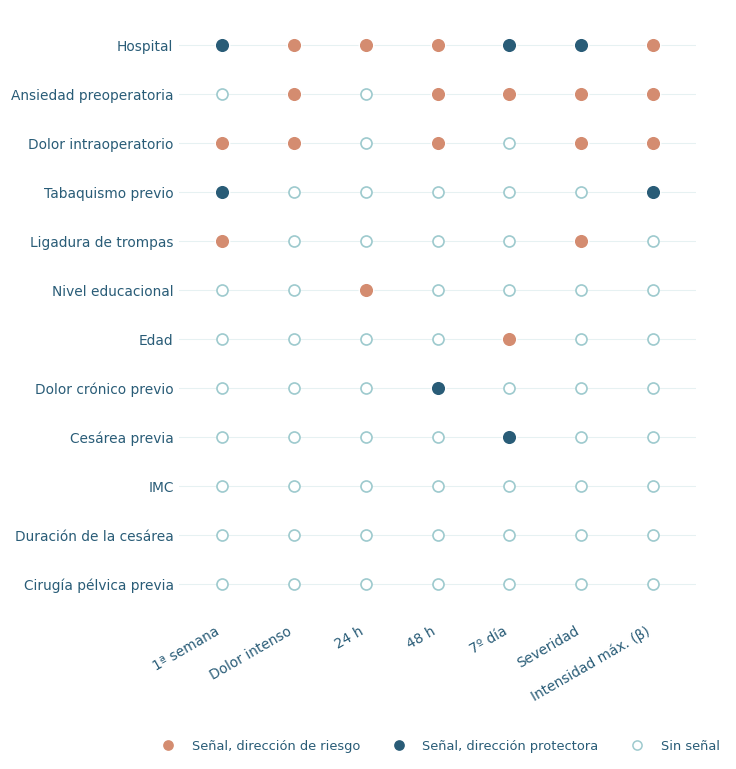

✔ tabla_M0_espinal.docx  (16 filas)
✔ tabla_M0_espinal.tex  (16 filas)  → requiere apaisada en el anexo


,Predictor,"Cohorte principal, OR (IC95 %)","Cohorte principal, p","Subcohorte espinal, OR (IC95 %)","Subcohorte espinal, p"
0,Hospital: HCVB (ref: HCUCH),"3,14 (1,78 – 5,54)","< 0,001","2,95 (1,65 – 5,28)","< 0,001"
1,Hospital: HLTB (ref: HCUCH),"0,25 (0,16 – 0,40)","< 0,001","0,24 (0,15 – 0,39)","< 0,001"
2,Hospital: HSJD (ref: HCUCH),"0,25 (0,15 – 0,42)","< 0,001","0,24 (0,14 – 0,40)","< 0,001"
3,Edad,"1,02 (0,98 – 1,05)","0,294","1,02 (0,98 – 1,05)","0,323"
4,IMC,"1,00 (0,97 – 1,03)","0,826","1,00 (0,97 – 1,03)","0,827"
5,Tabaquismo previo al embarazo: Sí (ref: No),"0,65 (0,44 – 0,96)","0,028","0,61 (0,41 – 0,91)","0,016"
6,Nivel educacional: Secundario (ref: Primario),"0,79 (0,33 – 1,88)","0,593","0,85 (0,35 – 2,06)","0,723"
7,Nivel educacional: Superior (ref: Primario),"0,89 (0,37 – 2,13)","0,794","0,93 (0,38 – 2,26)","0,866"
8,Cirugía pélvica previa: Sí (ref: No),"1,02 (0,56 – 1,84)","0,957","0,96 (0,53 – 1,74)","0,885"
9,Cesárea previa: Sí (ref: No),"0,87 (0,60 – 1,25)","0,440","0,78 (0,54 – 1,14)","0,197"


In [45]:
# Conjunto base (M0) en la subcohorte espinal, insumo del análisis de esa subcohorte.
# `asoc` ya trae el mismo conjunto ajustado en la cohorte completa.
ajuste_m0_esp = modell.ajustar(espinal, M0, catalogo)

consistencia_m0_esp = modell.clasificar_consistencia(
    modell.consistencia(espinal, M0, catalogo, DESENLACES),
    temprano=("dmg_24h",), tardio=("dmg_7d",), gravedad=("dolor_grave", "severidad"))

rendern.guardar(
    rendern.forest_comparado(
        asoc, ajuste_m0_esp,
        nombres=("Cohorte principal", "Subcohorte espinal"),
        etiquetas=ETIQUETA_FOREST),
    "fig_forest_base_espinal")

fig = rendern.consistencia(consistencia_m0_esp, etiquetas=ETIQUETA_DESENLACE,
                           etiquetas_var=ETIQUETA_CONSISTENCIA)
rendern.guardar(fig, "fig_consistencia_espinal_M0")
display(fig)

anexo_m0_espinal = tabula.tabla_logistica_comparada( {"Cohorte principal": asoc, "Subcohorte espinal": ajuste_m0_esp}, catalogo)
tabula.construir_docx(
    anexo_m0_espinal,
    tabula.Spec(config.TABLAS_MANUSCRITO["M0_espinal"],
                "Odds ratio del conjunto base (M0) en la cohorte completa y en la subcohorte espinal",
                nota="Mismo conjunto de covariables ajustado por separado en las dos cohortes, "
                     "sobre el desenlace compuesto. La columna «Cohorte principal» corresponde al "
                     "modelo de asociaciones ya reportado. "
                     "«Subcohorte espinal» es el mismo conjunto reajustado sobre "
                     "las 690 pacientes con anestesia espinal, antes de incorporar el manejo "
                     "anestésico recodificado.",
                apaisada=True))

anexo_m0_espinal

In [46]:
# Desplazamiento máximo de cada término frente a M0, insumo del análisis de la subcohorte espinal.
resumen_desplazamiento = (
    desplazamiento.assign(centro=desplazamiento["termino"].str.startswith(f"{config.CENTER_VAR}__"))
    .groupby(["termino", "label", "centro"], as_index=False)
    .agg(max_abs_pct=("cambio_pct", lambda s: s.abs().max()))
    .sort_values("max_abs_pct", ascending=False))

rendern.guardar(
    rendern.desplazamiento_terminos(
        resumen_desplazamiento,
        "Desplazamiento máximo de cada término frente al conjunto base (M0), subcohorte espinal",
        umbral=config.CAMBIO_ESTIMACION_UMBRAL),
    "fig_desplazamiento_espinal")


✔ fig_desplazamiento_espinal.png · fig_desplazamiento_espinal.svg


✔ recuperado permutacion_espinal_periop.parquet
✔ fig_consenso_permutacion_espinal.png · fig_consenso_permutacion_espinal.svg


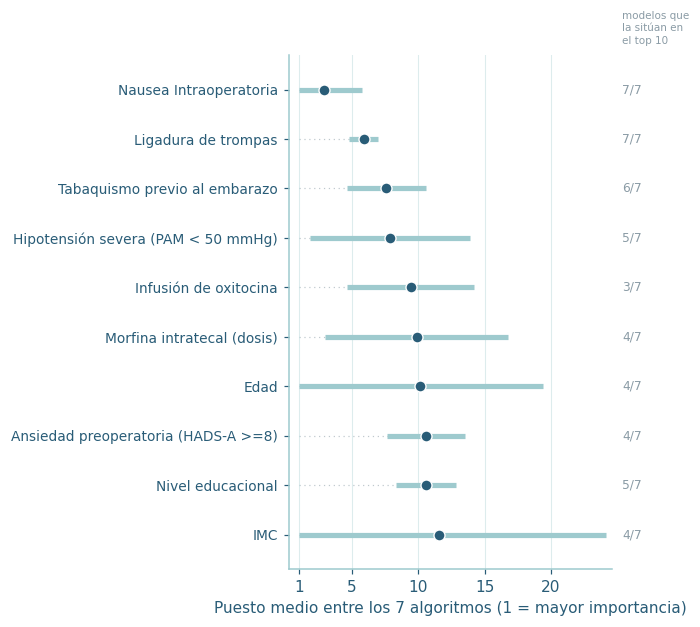

,var_rename,rango_medio,rango_de,n_modelos_top10
0,nauseas_io,2.86,2.85,7
1,lig_trompas,5.86,1.07,7
2,tbq,7.57,2.99,6
3,hipotension_io,7.86,6.01,5
4,oxitoc_inf,9.43,4.79,3
5,morf_rec,9.86,6.89,4
6,edad,10.14,9.25,4
7,hads_a,10.57,2.94,4
8,ne,10.57,2.30,5
9,imc,11.57,12.58,4


In [47]:
periop_esp = datos[("espinal", "sin_centro", "periop")]

permutacion_esp = evaluar.persistir(
    RUTA / "permutacion_espinal_periop.parquet",
    lambda: evaluar.importancia_permutacion(periop_esp))
consenso_esp = evaluar.consenso(permutacion_esp, top=TOP_CONSENSO)

fig = rendern.consenso_permutacion(
    consenso_esp, etiquetas=ETIQUETA, top=TOP_CONSENSO, columna=COLUMNA_CONSENSO)
rendern.guardar(fig, "fig_consenso_permutacion_espinal")
display(fig)

consenso_esp.head(TOP_CONSENSO)[["var_rename", "rango_medio", "rango_de", COLUMNA_CONSENSO]].round(2)

In [48]:
# Dirección de las asociaciones de los predictores de mayor peso, para la interpretabilidad
# del modelo. No es un segundo análisis de factores. Se ajusta sobre la matriz preprocesada
# del arco predictivo, de modo que el OR de una ordinal sea el paso de un nivel y el de una
# numérica una desviación estándar, que es la parametrización que reporta su anexo.
LOGISTICA = {"principal": modell.coeficientes(datos[("principal", "sin_centro", "periop")],
                                              catalogo),
             "espinal":   modell.coeficientes(datos[("espinal", "sin_centro", "periop")],
                                              catalogo)}

# Una tabla por cohorte, cada una con el top TOP_CONSENSO de su propio consenso: las dos
# especificaciones no comparten predictores, de modo que una sola tabla cruzada dejaría media
# columna en «no incluida». El mapa var_rename → puesto selecciona y ordena a la vez, y es el
# mismo conjunto que recibe panel SHAP en esta cohorte.
PUESTOS = {coh: {v: i + 1 for i, v in
                 enumerate(d.nsmallest(TOP_CONSENSO, "rango_medio")["var_rename"])}
           for coh, d in [("principal", consenso), ("espinal", consenso_esp)]}

NOTA_LOGISTICA = (
    f"Los {TOP_CONSENSO} primeros predictores del consenso de importancia por permutación de "
    "esta cohorte, en ese orden; la columna «Puesto» es esa posición, la misma que ocupan en "
    "su figura de consenso y en sus paneles de dependencia. El odds ratio corresponde a una "
    "desviación estándar en las variables numéricas, al paso de un nivel en las ordinales y a "
    "la presencia frente a la ausencia en las binarias. No procede del modelo de asociaciones "
    "(\\cref{sec:factores-asociados-dolor-agudo}).")

logistica_consenso = {}
for coh, clave, titulo in [
        ("principal", "RL_periop_principal",
         "Anexo. Odds ratio de la regresión logística perioperatoria en la cohorte principal"),
        ("espinal", "RL_periop_espinal",
         "Anexo. Odds ratio de la regresión logística perioperatoria en la subcohorte espinal")]:
    logistica_consenso[coh] = tabula.tabla_logistica_consenso(LOGISTICA[coh], PUESTOS[coh])
    tabula.construir_docx(
        logistica_consenso[coh],
        tabula.Spec(config.TABLAS_MANUSCRITO[clave], titulo, nota=NOTA_LOGISTICA))

display(logistica_consenso["principal"], logistica_consenso["espinal"])

✔ tabla_RL_logistica_periop_principal.docx  (10 filas)
✔ tabla_RL_logistica_periop_principal.tex  (10 filas)
✔ tabla_RL_logistica_periop_espinal.docx  (10 filas)
✔ tabla_RL_logistica_periop_espinal.tex  (10 filas)


,Puesto,Predictor,OR (IC95 %),p
0,1,Morfina intratecal,"1,42 (1,20 – 1,69)","< 0,001"
1,2,Paracetamol postoperatorio,"0,20 (0,11 – 0,35)","< 0,001"
2,3,Nausea Intraoperatoria,"2,18 (1,23 – 3,89)","0,008"
3,4,Edad,"1,20 (0,99 – 1,45)","0,065"
4,5,Bupivacaína intratecal,"0,84 (0,66 – 1,06)","0,143"
5,6,Ketorolaco intraoperatorio,"0,82 (0,56 – 1,20)","0,296"
6,7,Ligadura de trompas,"1,45 (0,99 – 2,14)","0,058"
7,8,Hipotensión severa (PAM < 50 mmHg),"2,33 (1,03 – 5,27)","0,043"
8,9,Bolo de oxitocina (Retracción),"1,21 (0,80 – 1,83)","0,377"
9,10,Paracetamol intraoperatorio,"0,61 (0,35 – 1,05)","0,072"


,Puesto,Predictor,OR (IC95 %),p
0,1,Nausea Intraoperatoria,"2,35 (1,35 – 4,10)","0,003"
1,2,Ligadura de trompas,"1,60 (1,10 – 2,33)","0,013"
2,3,Tabaquismo previo al embarazo,"0,58 (0,40 – 0,85)","0,005"
3,4,Hipotensión severa (PAM < 50 mmHg),"2,88 (1,32 – 6,29)","0,008"
4,5,Infusión de oxitocina,"1,37 (0,88 – 2,15)","0,166"
5,6,Morfina intratecal (dosis),"1,11 (0,88 – 1,40)","0,366"
6,7,Edad,"1,11 (0,93 – 1,34)","0,244"
7,8,Ansiedad preoperatoria (HADS-A >=8),"1,41 (0,93 – 2,16)","0,109"
8,9,Nivel educacional,"1,27 (0,95 – 1,71)","0,103"
9,10,IMC,"1,01 (0,84 – 1,23)","0,887"


✔ fig_reordenamiento_espinal.png · fig_reordenamiento_espinal.svg


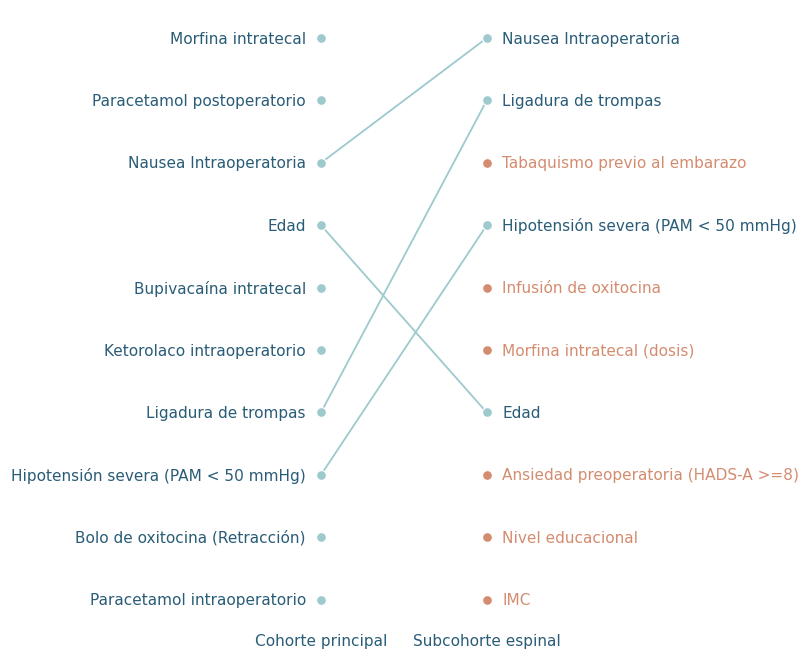

In [49]:
# Desplazamiento de cada predictor entre cohortes, en lugar de dos ordenamientos por separado
fig = rendern.reordenamiento(consenso, consenso_esp, etiquetas=ETIQUETA, top=TOP_CONSENSO,
                             nombres=("Cohorte principal", "Subcohorte espinal"))
rendern.guardar(fig, "fig_reordenamiento_espinal")
fig

In [50]:
shap_esp = evaluar.persistir(
    RUTA / "shap_espinal_periop.parquet",
    lambda: evaluar.shap_valores(periop_esp))

✔ recuperado shap_espinal_periop.parquet


✔ fig_dependencia_shap_espinal.png · fig_dependencia_shap_espinal.svg


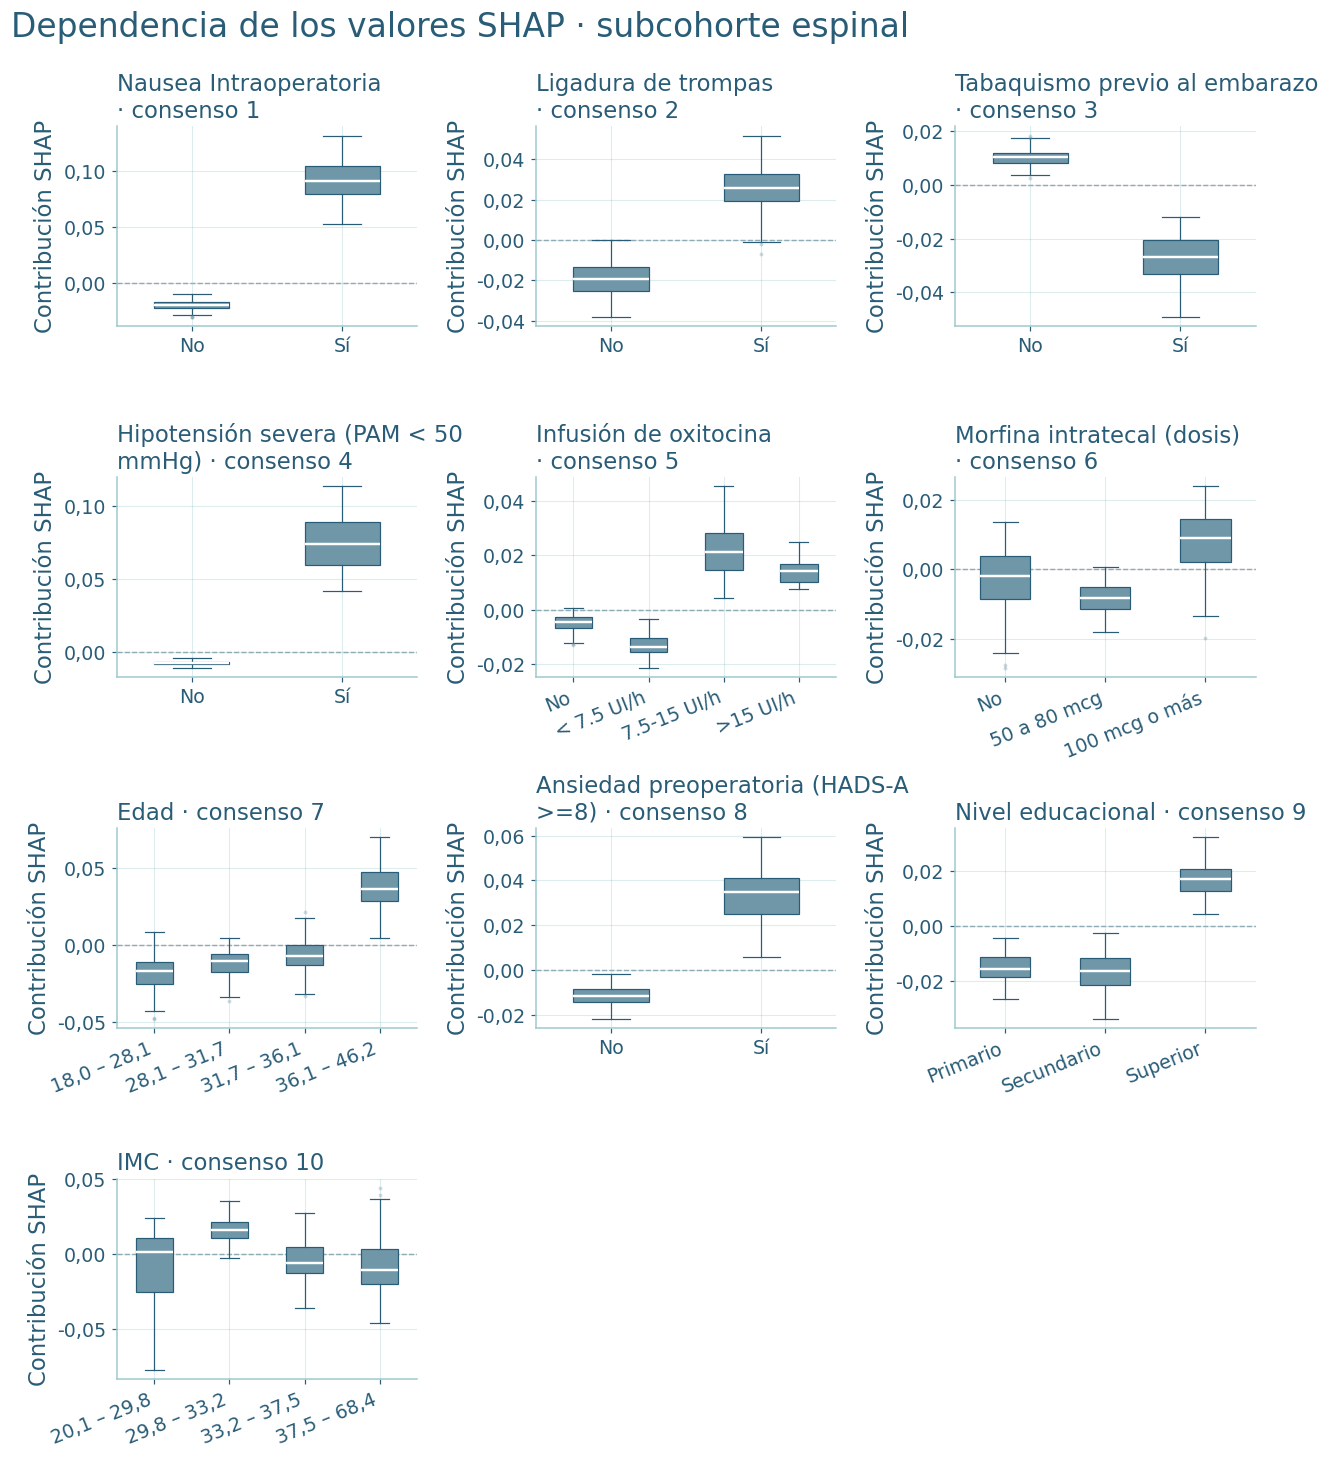

In [51]:
# Dependencia de los valores SHAP en la subcohorte espinal, contraparte de la principal.
# La selección se hace contra el consenso de esta cohorte y no contra el de la principal: la
# especificación espinal retira la analgesia postoperatoria y recodifica el manejo
# intraoperatorio, de modo que las columnas disponibles no son las mismas.
paneles_esp = evaluar.paneles_shap(consenso_esp, shap_esp, criterio=CRITERIO_PANELES_SHAP,
                                   top=TOP_CONSENSO)
columnas_shap_esp = paneles_esp["var_rename"].tolist()

tipos_shap = dict(zip(catalogo["var_rename"], catalogo["conceptual_type"]))
niveles_shap_esp = {v: modell.niveles_declarados(catalogo, v, espinal[v] if v in espinal.columns else None)
                    for v in columnas_shap_esp}

fig = rendern.dependencia_shap(shap_esp, columnas_shap_esp,
                             "Dependencia de los valores SHAP · subcohorte espinal",
                             etiquetas=ETIQUETA, tipos=tipos_shap, niveles=niveles_shap_esp,
                             rangos=dict(zip(paneles_esp["var_rename"], paneles_esp["puesto"])),
                             ncols=3)
rendern.guardar(fig, "fig_dependencia_shap_espinal")
fig

### 10.5 Incorporación de la variable centro

Se contrasta el escenario que incorpora el hospital como predictor frente al principal, que lo
excluye. Interesa cuánto valor añadido conserva la información perioperatoria cuando el centro está
en el modelo, y cómo se reordena la importancia de los demás predictores.

In [52]:
# Incorporación del centro: mismo par, otro escenario
con_centro = evaluar.comparacion_pareada(
    principal, pares_centro, extraccion,
    etiquetas=("sin centro", "con centro"))

con_centro[["sin centro", "con centro", "delta_auc", "delta_auc_ic_low",
            "delta_auc_ic_high", "p_unilateral"]].round(4)

,sin centro,con centro,delta_auc,delta_auc_ic_low,delta_auc_ic_high,p_unilateral
0,principal · sin_centro · periop · ElasticNet,principal · con_centro · periop · ElasticNet,0.0586,0.0341,0.0835,0.000
1,principal · sin_centro · periop · GBM,principal · con_centro · periop · GBM,0.0768,0.0504,0.1063,0.000
2,principal · sin_centro · periop · LASSO,principal · con_centro · periop · LASSO,0.0465,0.0228,0.0704,0.001
3,principal · sin_centro · periop · LR,principal · con_centro · periop · LR,0.0500,0.0262,0.0732,0.001
4,principal · sin_centro · periop · RF,principal · con_centro · periop · RF,0.0326,0.0112,0.0535,0.002
5,principal · sin_centro · periop · SVM,principal · con_centro · periop · SVM,0.0045,-0.0153,0.0227,0.343
6,principal · sin_centro · periop · XGB,principal · con_centro · periop · XGB,0.0456,0.0207,0.0714,0.000
7,principal · sin_centro · preop · ElasticNet,principal · con_centro · preop · ElasticNet,0.1581,0.1115,0.2018,0.000
8,principal · sin_centro · preop · GBM,principal · con_centro · preop · GBM,0.1663,0.1201,0.2087,0.000
9,principal · sin_centro · preop · LASSO,principal · con_centro · preop · LASSO,0.1566,0.1114,0.1992,0.000


✔ fig_valor_anadido_centro.png · fig_valor_anadido_centro.svg
ΔAUC promedio · sin centro 0.156 · con centro 0.027 · caída 83 %


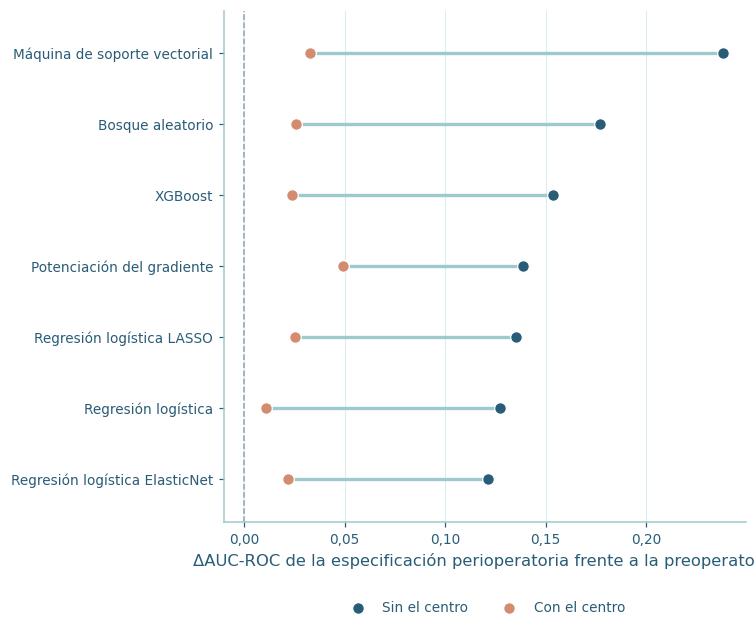

In [53]:
# Figura · valor añadido con y sin la variable centro. Los siete algoritmos, no solo
# la regresión logística: lo que hay que ver es que las siete líneas se acortan a la vez.
fig = rendern.valor_anadido_por_escenario(pareada)
rendern.guardar(fig, "fig_valor_anadido_centro")

_m = (pareada.assign(esc=pareada["referencia"].str.split("·").str[1].str.strip())
      .groupby("esc")["delta_auc"].mean())
print(f"ΔAUC promedio · sin centro {_m['sin_centro']:.3f} · con centro {_m['con_centro']:.3f} "
      f"· caída {100 * (1 - _m['con_centro'] / _m['sin_centro']):.0f} %")

fig


In [54]:
# Reordenamiento del consenso al incorporar el centro
permutacion_cc = evaluar.persistir(
    RUTA / "permutacion_principal_periop_con_centro.parquet",
    lambda: evaluar.importancia_permutacion(datos[("principal", "con_centro", "periop")]))

consenso_cc = evaluar.consenso(permutacion_cc)
(consenso[["var_rename", "rango_medio"]]
 .merge(consenso_cc[["var_rename", "rango_medio"]], on="var_rename",
        how="outer", suffixes=(" sin centro", " con centro"))
 .sort_values("rango_medio con centro").head(12).round(2))

✔ recuperado permutacion_principal_periop_con_centro.parquet


,var_rename,rango_medio sin centro,rango_medio con centro
26,hosp,NaN,2.43
29,morf_it,2.29,3.29
35,paracetamol_24h,2.29,5.43
12,bupi_it,9.57,5.57
19,edad,6.43,6.43
30,nauseas_io,5.57,7.86
20,eg,13.86,11.29
28,lig_trompas,11.57,12.00
37,tbq,17.86,13.57
9,an_ketorolaco,9.71,13.57


✔ fig_reordenamiento_centro.png · fig_reordenamiento_centro.svg


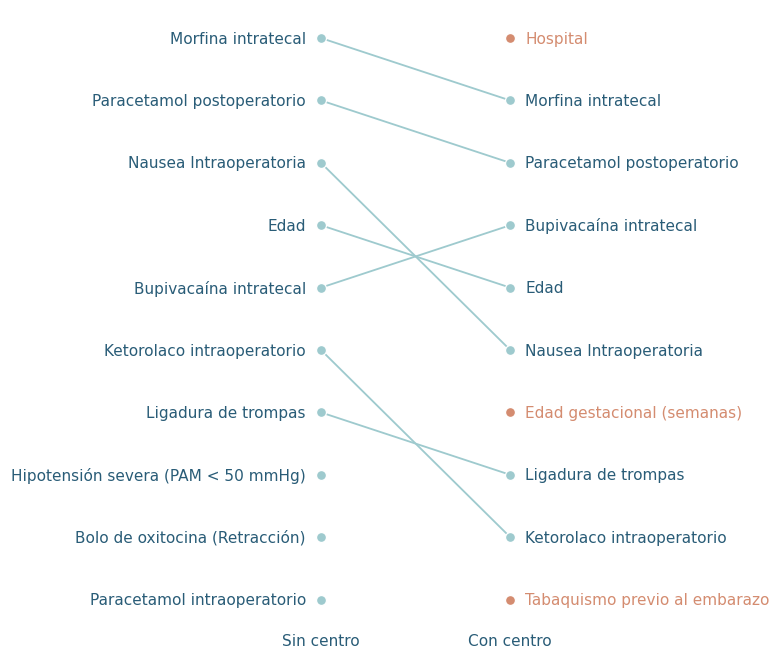

In [55]:
fig = rendern.reordenamiento(consenso, consenso_cc, etiquetas=ETIQUETA, top=TOP_CONSENSO)
rendern.guardar(fig, "fig_reordenamiento_centro")
fig

### 10.6 Transportabilidad entre centros

Cada modelo se entrena excluyendo un hospital y se evalúa en el hospital retenido, repitiendo el
procedimiento para los cuatro centros. La discriminación así obtenida estima hasta qué punto los
patrones aprendidos son comunes entre centros y no propios de aquel en que se entrenó.

El procedimiento se aplica a la cohorte principal y a la subcohorte espinal.

In [56]:
# Transportabilidad: entrenar sin un centro y evaluar en él
iecv = evaluar.persistir(
    RUTA / "iecv_principal_periop.parquet",
    lambda: evaluar.transportabilidad(periop, cohorte.loc[periop.X.index, config.CENTER_VAR]))

# Resumen descriptivo declarado en los métodos: promedio del AUC entre centros retenidos.
resumen_iecv = evaluar.promedio_por_centro(iecv)

print(f"promedio entre modelos {resumen_iecv['auc_promedio'].mean():.2f} "
      f"· por centro entre {iecv['auc'].min():.2f} y {iecv['auc'].max():.2f}")
resumen_iecv.round(3)

✔ recuperado iecv_principal_periop.parquet
promedio entre modelos 0.54 · por centro entre 0.47 y 0.65


,cohorte,escenario,especificacion,algoritmo,centros,auc_promedio,auc_min,auc_max
0,principal,sin_centro,periop,SVM,4,0.565,0.508,0.652
1,principal,sin_centro,periop,GBM,4,0.562,0.507,0.632
2,principal,sin_centro,periop,LASSO,4,0.544,0.500,0.593
3,principal,sin_centro,periop,RF,4,0.543,0.466,0.653
4,principal,sin_centro,periop,LR,4,0.537,0.486,0.582
5,principal,sin_centro,periop,ElasticNet,4,0.534,0.490,0.595
6,principal,sin_centro,periop,XGB,4,0.521,0.485,0.599


✔ fig_transportabilidad_centros.png · fig_transportabilidad_centros.svg


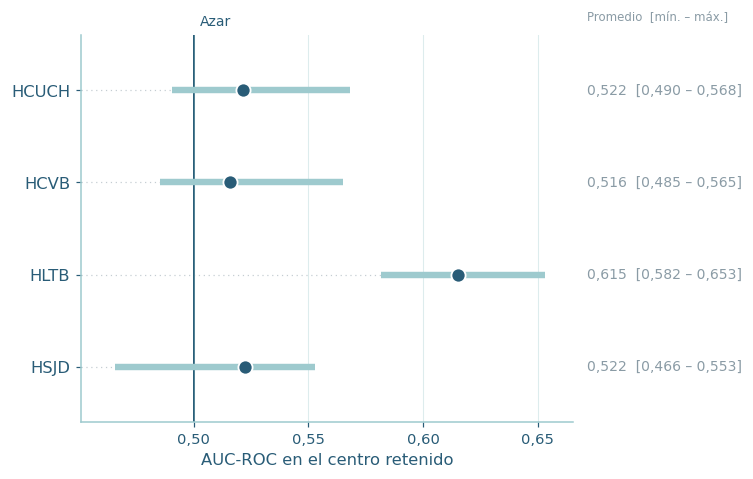

In [57]:
# Figura · transportabilidad por centro. Una fila por centro retenido: el punto es
# el promedio de los siete algoritmos y la barra su rango, de modo que se lea que la
# dispersión está entre hospitales y no entre modelos. La barra no es un intervalo de
# confianza.
fig = rendern.transportabilidad_por_centro(
    iecv, "Transportabilidad entre centros · especificación perioperatoria")
rendern.guardar(fig, "fig_transportabilidad_centros")
fig


In [58]:
iecv_esp = evaluar.persistir(
    RUTA / "iecv_espinal_periop.parquet",
    lambda: evaluar.transportabilidad(
        periop_esp, espinal.loc[periop_esp.X.index, config.CENTER_VAR]))

resumen_iecv_esp = evaluar.promedio_por_centro(iecv_esp)
print(f"espinal · promedio {resumen_iecv_esp['auc_promedio'].mean():.2f} "
      f"· por centro entre {iecv_esp['auc'].min():.2f} y {iecv_esp['auc'].max():.2f}")
resumen_iecv_esp.round(3)

✔ recuperado iecv_espinal_periop.parquet
espinal · promedio 0.54 · por centro entre 0.45 y 0.61


,cohorte,escenario,especificacion,algoritmo,centros,auc_promedio,auc_min,auc_max
0,espinal,sin_centro,periop,XGB,4,0.548,0.512,0.577
1,espinal,sin_centro,periop,GBM,4,0.547,0.516,0.578
2,espinal,sin_centro,periop,RF,4,0.543,0.446,0.612
3,espinal,sin_centro,periop,ElasticNet,4,0.542,0.499,0.579
4,espinal,sin_centro,periop,LASSO,4,0.540,0.490,0.592
5,espinal,sin_centro,periop,LR,4,0.538,0.486,0.592
6,espinal,sin_centro,periop,SVM,4,0.535,0.487,0.586


In [59]:
# Anexo · transportabilidad. Una columna por centro retenido, que no participó del entrenamiento.
anexo_transportabilidad = tabula.tabla_transportabilidad(iecv)
tabula.construir_docx(
    anexo_transportabilidad,
    tabula.Spec(config.TABLAS_MANUSCRITO["AX_transportabilidad"],
                "Anexo. Transportabilidad entre centros de la especificación perioperatoria",
                nota="AUC-ROC obtenido en el centro retenido. Validación cruzada interna-externa "
                     "dejando un centro fuera, análisis exploratorio."))

anexo_transportabilidad

✔ tabla_AX_transportabilidad.docx  (7 filas)
✔ tabla_AX_transportabilidad.tex  (7 filas)


centro,Algoritmo,HCUCH,HCVB,HLTB,HSJD,Promedio
0,SVM,"0,508","0,565","0,652","0,537","0,565"
1,GBM,"0,568","0,540","0,632","0,507","0,562"
2,LASSO,"0,529","0,500","0,593","0,553","0,544"
3,RF,"0,523","0,530","0,653","0,466","0,543"
4,LR,"0,534","0,486","0,582","0,545","0,537"
5,ElasticNet,"0,490","0,503","0,595","0,549","0,534"
6,XGB,"0,499","0,485","0,599","0,499","0,521"


## 11. Salidas y verificación

El cuaderno cierra con el contrato de reproducibilidad. Las magnitudes que sostienen las cifras
publicadas se comprueban una a una, de modo que el cuaderno falle si alguna deja de coincidir, en vez
de emitir resultados distintos sin advertirlo.

In [60]:

assert (a["n"], a["eventos"]) == (714, 423), "cohorte de ajuste del modelo de asociaciones"
assert a["n_parametros"] - 1 == 16, "términos del modelo de asociaciones"
assert {(c, e): datos[(c, "sin_centro", e)].X.shape[1]
        for c in ("principal", "espinal") for e in config.ESPECIFICACIONES} == {
            ("principal", "preop"): 16, ("principal", "periop"): 38,
            ("espinal", "preop"): 15, ("espinal", "periop"): 31}, \
    "composición de las cuatro especificaciones"
assert len(escalera) == 6, "peldaños de la escalera espinal"
assert len(descomposicion) == 10, "filas de la descomposición del ajuste"
assert consistencia["desenlace"].nunique() == len(DESENLACES), "operacionalizaciones del desenlace"
assert oof.groupby(list(evaluar.CLAVES)).ngroups == len(datos) * len(config.ALGORITMOS), \
    "combinaciones de la validación cruzada"

print(f"modelo de asociaciones      n {a['n']}  eventos {a['eventos']}  términos {a['n_parametros'] - 1}")
print(f"  EPV                       {a['eventos'] / (a['n_parametros'] - 1):.2f}")
print(f"  VIF equivalente máximo    {vif['VIF_equivalente'].max():.2f}")
print(f"predictores candidatos      {len(candidatos)}  estables {int(estabilidad['estable'].sum())}")
print(f"escalera espinal            {len(escalera)} peldaños  ·  EPV mínimo {escalera['EPV'].min():.2f}")
print(f"descomposición espinal      {len(descomposicion)} filas")
print(f"tablas en                   {config.TABLAS.relative_to(config.REPO)}")

modelo de asociaciones      n 714  eventos 423  términos 16
  EPV                       26.44
  VIF equivalente máximo    1.25
predictores candidatos      39  estables 16
escalera espinal            6 peldaños  ·  EPV mínimo 20.55
descomposición espinal      10 filas
tablas en                   salida/outputs/tables
